# Sub-Doppler rubidium atom cooling using a programmable agile integrated PZT-on-SiN resonator

**Andrei Isichenko**<sup>1†</sup>, **Steven Carpenter**<sup>2†</sup>, **Nick Montifiore**<sup>1</sup>, **Jiawei Wang**<sup>1</sup>, **Mayand Dangi**<sup>3</sup>, **Nitesh Chauhan**<sup>1</sup>, **Pritha Mukherjee**<sup>3</sup>, **Xuting Yang**<sup>4</sup>, **Nitin Indukuri**<sup>1</sup>, **Mark W. Harrington**<sup>1</sup>, **Chuan Zhong**<sup>1</sup>, **Iain M. Kierzewski**<sup>5</sup>, **Ryan Q. Rudy**<sup>5</sup>, **Jennifer T. Choy**<sup>2,3∗</sup>, and **Daniel J. Blumenthal**<sup>1∗</sup>

<sup>1</sup>Department of Electrical and Computer Engineering, University of California Santa Barbara, Santa Barbara, California 93106, USA

<sup>2</sup>Department of Physics, University of Wisconsin-Madison, Madison, Wisconsin 53706, USA

<sup>3</sup>Department of Electrical and Computer Engineering, University of Wisconsin-Madison, Madison, Wisconsin 53706, USA

<sup>4</sup>Department of Materials Science and Engineering, University of Wisconsin-Madison, Madison, Wisconsin 53706, USA

<sup>5</sup>U.S. Army Research Laboratory, Adelphi, Maryland 20783, USA

†These authors contributed equally: Andrei Isichenko, Steven Carpenter

∗Corresponding Authors: jennifer.choy@wisc.edu, danb@ucsb.edu

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline

# Local NCOMMS data repository (run kernel with this folder as cwd)
DATA_REPO = Path.cwd()
assert (DATA_REPO / "resonators.py").exists(), (
    f"Expected resonators.py in cwd; got {DATA_REPO}. "
    "Open/run the notebook from the data_repository folder."
)
plt.style.use(DATA_REPO / "plot_style.mplstyle")

from resonators import (
    calibrate_mzi,
    crop_rescale_res_mzi,
    linear_fit,
    moving_average,
    q_fit_lz,
)

def data_join(*parts):
    """Absolute path under DATA_REPO."""
    return str(DATA_REPO.joinpath(*parts))

def data_list_files(*parts, suffix=None):
    """Basenames in a DATA_REPO subdirectory (optional suffix filter, e.g. '.tiff')."""
    d = DATA_REPO.joinpath(*parts)
    names = [p.name for p in d.iterdir() if p.is_file() and not p.name.startswith(".")]
    if suffix is not None:
        names = [n for n in names if n.endswith(suffix)]
    return names


## Figure 2

### Fig. 2b

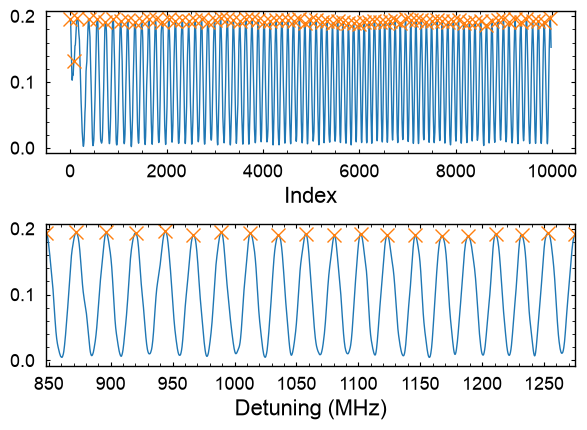

-----------Q Analysis------------
Loss rates = 31.94 , 137.53 MHz
Total loss rate = 169.47 MHz
Intrinsic Q = 12.03 2.79 M
Loaded Q = 2.27 M
Splitting 2g = 0.00 MHz
Propagation loss = 4.85,20.90 dB/m
ER = 4.11 dB


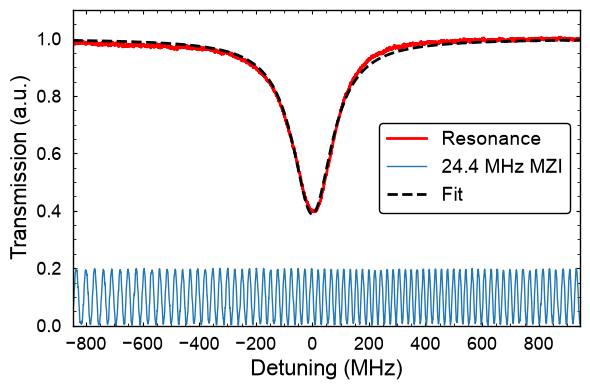

In [2]:
def normalize(vec):
    return vec/np.max(vec)


base_path = data_join('figure2', 'fig2b')
filename = 'Die6_1ring_1bus_d6_1p15um_gap_MZIFSR_24MHz_1.csv'
path = os.path.join(base_path, filename)

mzi_fsr = 24.4 # MHz

wg_ng = 1.671032 # from tidy3d: https://tidy3d.simulation.cloud/workbench?taskId=pa-353017eb-834b-4e7a-809e-ceadcda93109

y_res, y_mzi = crop_rescale_res_mzi(path, X_window = 0, Nmean = 10, mzi_debug = False)
f = calibrate_mzi(y_mzi, fsr_mzi = mzi_fsr, Nmean = 15, Nbetween = 50, peaks_debug = True)
q_data = q_fit_lz(f, y_res, y_mzi, fsr_mzi=mzi_fsr, lw_guess = [10, 100], fit_model= 0, add_drop=False, wl_res = 780e-9, wg_ng = wg_ng, fit_plot=False)

plt.figure(figsize=(6,4))
plt.plot(q_data['f detuning'], q_data['y res'], color='red', lw=2, label='Resonance')
fsr_mzi = q_data['MZIFSR']
plt.plot(q_data['f detuning'], q_data['y mzi'], color='#2177b4',label=f'{fsr_mzi:.1f} MHz MZI')
plt.plot(q_data['f detuning'], q_data['y fit'],  c='black', ls='--', lw=2, label='Fit')
plt.xlim((min(q_data['f detuning'])+100, max(q_data['f detuning'])-90))
plt.ylim((0, 1.1))
plt.xlabel('Detuning (MHz)')
plt.ylabel('Transmission (a.u.)')
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()


### Fig. 2c

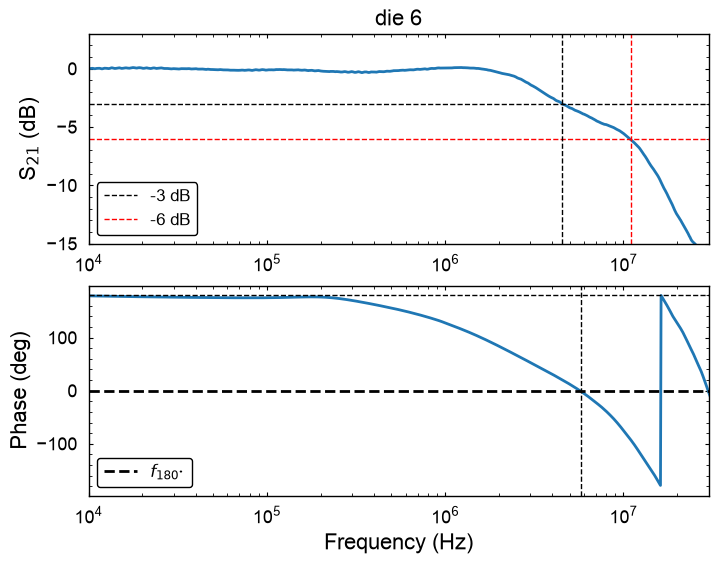

In [3]:
def get_pna_data(path):
    df = pd.read_csv(path, header=5, encoding='unicode_escape')
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna(how='all')
    return df

plt.figure(figsize=(8, 6))
plt.subplot(2,1,1)

base_path = data_join('figure2', 'fig2c')
filename = f'die6_d6_S21_BPD_5.csv'
path = os.path.join(base_path, filename)
df_die6_d6 = get_pna_data(path)
S21_amp_die6_d6_run = df_die6_d6['S21(DB)'] + 3.9 # - np.mean(df_die6_d6['S21(DB)'][0:10])

plt.subplot(2,1,1)
plt.semilogx(df_die6_d6['Freq(Hz)'], S21_amp_die6_d6_run, lw=2)
plt.axhline(-3, ls='--', color='k', lw=1, label='-3 dB')
plt.axhline(-6, ls='--', color='r', lw=1, label='-6 dB')
plt.axvline(4.5e6, ls='--', color='k')
plt.axvline(11e6, ls='--', color='red')
plt.legend()
plt.ylabel('S$_{21}$ (dB)')
plt.ylim([-15, 3])
plt.xlim([1e4, 3e7])
plt.title('die 6')
plt.subplot(2,1,2)
plt.semilogx(df_die6_d6['Freq(Hz)'], df_die6_d6['S21(DEG)'], lw=2)
plt.axhline(180, ls='--', lw=1, color='k')
plt.axhline(0, ls='--', lw=2, color='k', label=r'$f_{180^{\circ}}$')
plt.axvline(5.8e6, ls='--', color='k')
plt.ylabel('Phase (deg)') 
plt.xlabel('Frequency (Hz)')
plt.xlim([1e4, 3e7])
plt.legend()
#plt.savefig('PNA_die6_AC_meas.pdf')
plt.show()


### Fig. 2d

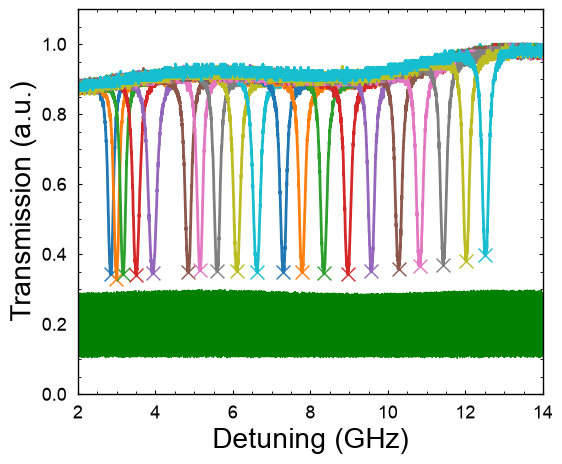

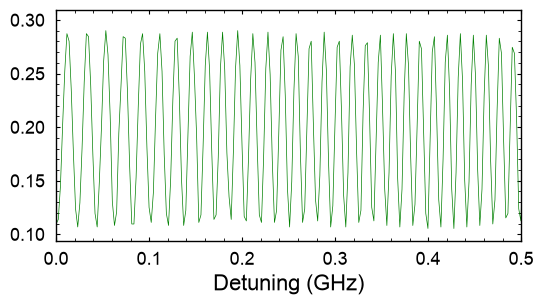

In [4]:
debug = False
include_split = False
fit_model = 0
lw_guess = [100, 100.0]

smooth_val = 25

MZI_FSR = 24.8 # MHz

PZT_voltages = [0.0,0.5,1.0,1.5,2.0,3.0, 3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,9.5,10.0]

res_freq_vals = []

base_path = data_join('figure2', 'fig2de')

plt.figure(figsize=(6,5))

Die_num = 6
device_num = 6 # gap 1.15 um

for voltage in PZT_voltages:
    voltage_str = str(voltage).replace('.', 'p')
    filename = f'Q_780PZT_die6_singlering_device6_MZIFSR24p8MHz_35p228C_PZT_{voltage_str}V.csv'
    #print(filename)
    path = os.path.join(base_path, filename)
        
    df = pd.read_csv(path)
    start_idx = 0
    end_idx = -1
    df = df[start_idx:end_idx]
    
    Nmean = 1
    y_res = df['trans_pd'].to_numpy()
    y_res = moving_average(y_res, Nmean)  # moving average
    y_res = y_res/np.max(y_res) # normalized data

    y_mzi = df['mzi_pd'].to_numpy()
    y_mzi = moving_average(y_mzi, Nmean)  # moving average
    y_mzi = y_mzi / np.max(y_mzi)*0.2  # normalized data

    freq = calibrate_mzi(y_mzi, fsr_mzi = MZI_FSR, Nmean = 2, Nbetween = 5, peaks_debug = debug) 

    q_data = q_fit_lz(freq, y_res, y_mzi, fsr_mzi=MZI_FSR, lw_guess = lw_guess, 
                      wl_res = 780e-9, fit_model=fit_model, add_drop=False, wg_ng = 1.48, fit_plot=False, print_result=False)

    freq = freq - freq[0]
    
    res_resample = q_data['y res']
    mzi_resample = q_data['y mzi']
    y_fit = q_data['y fit']
    
    peak_position = freq[np.argmin(y_fit)]
    res_freq_vals.append(peak_position)
    
    if voltage==0:
        plt.plot(freq/1e3, moving_average(q_data['y mzi'],1) * 1 + 0.1, '-g', linewidth=1, label='MZI')
    
    transmission_to_plot = normalize(res_resample)
    plt.plot(freq/1e3, transmission_to_plot, linewidth=2)#, label=f'PZT = {voltage:.1f} V')
    plt.scatter(peak_position/1e3, transmission_to_plot[np.argmin(res_resample)], marker='x')

plt.xlabel('Detuning (GHz)', fontsize=20)
plt.ylabel('Transmission (a.u.)', fontsize=20)
plt.ylim([0,1.1])
plt.xlim([2, 14])
plt.show()

plt.figure(figsize=(6,3))
plt.plot(freq/1e3, moving_average(q_data['y mzi'],1) * 1 + 0.1, '-g', linewidth=0.5, label='MZI')
plt.xlabel('Detuning (GHz)')
plt.xlim([0,0.5])
plt.show()


### Fig. 2e

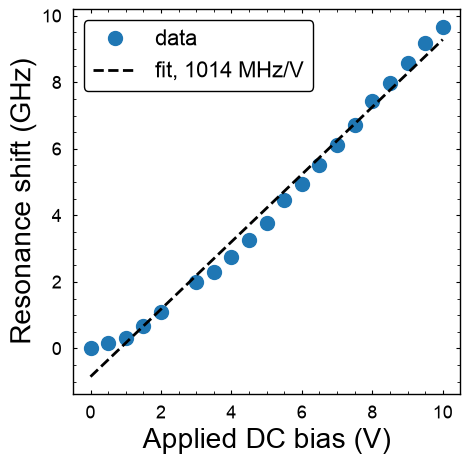

In [5]:
PZT_voltages = np.asarray(PZT_voltages)

res_shift = res_freq_vals - res_freq_vals[0]
m, b = linear_fit(PZT_voltages, res_shift)
plt.figure(figsize=(5,5))
plt.plot(PZT_voltages, (res_freq_vals - res_freq_vals[0])/1e3,'o', label='data')
plt.plot(PZT_voltages, (m*PZT_voltages + b)/1e3,'--', lw=2, color='k', label=f'fit, {m:.0f} MHz/V')
plt.xlabel('Applied DC bias (V)', fontsize=20)
plt.ylabel('Resonance shift (GHz)', fontsize=20)
plt.legend(fontsize=16)
plt.show()


### Fig. 2f

Add-thru resonators: non-split Qmeasure and DC tuning (dies 2, 3, 4, 7, 8, 10).


In [6]:
FIG2F_DATA = DATA_REPO / 'figure2' / 'fig2f'

def fig2f_join(*parts):
    """Absolute path under the fig2f data directory."""
    return str(FIG2F_DATA.joinpath(*parts))

def fig2f_csv_names(*parts):
    """CSV basenames in a fig2f subdirectory."""
    d = FIG2F_DATA.joinpath(*parts)
    return [p.name for p in d.glob('*.csv')]


#### Die 2

##### Q-measure

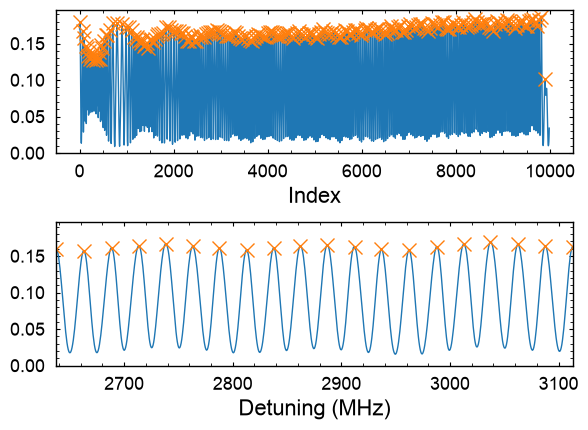

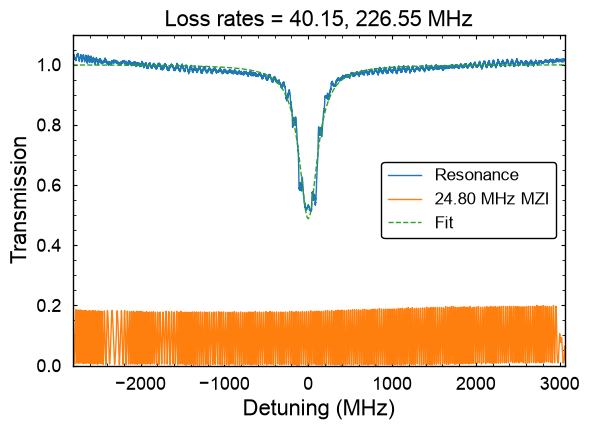

-----------Q Analysis------------
Loss rates = 40.15 , 226.55 MHz
Total loss rate = 266.69 MHz
Intrinsic Q = 9.57 1.70 M
Loaded Q = 1.44 M
Splitting 2g = 0.00 MHz
Propagation loss = 5.42,30.57 dB/m
ER = 3.11 dB


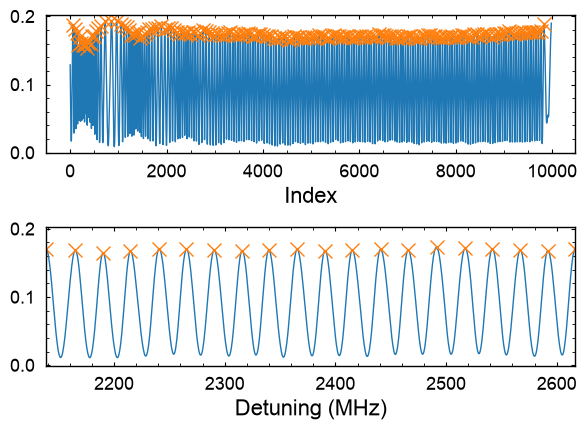

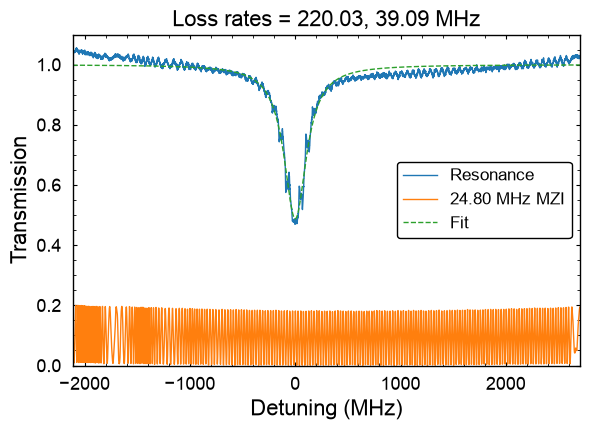

-----------Q Analysis------------
Loss rates = 220.03 , 39.09 MHz
Total loss rate = 259.12 MHz
Intrinsic Q = 1.75 9.83 M
Loaded Q = 1.48 M
Splitting 2g = 0.00 MHz
Propagation loss = 29.69,5.28 dB/m
ER = 3.12 dB


In [7]:
base_path = fig2f_join('die2')
filename = 'Qmeasure_Die2_1ring_1bus_1p15um_gap_MZIFSR_24p8MHz_780p15nm_run1.csv'
path = os.path.join(base_path, filename)

mzi_fsr = 24.8 # MHz

wg_ng = 1.4837

y_res, y_mzi = crop_rescale_res_mzi(path, X_window = 0, Nmean = 3, mzi_debug = False)
f = calibrate_mzi(y_mzi, fsr_mzi = mzi_fsr, Nmean = 15, Nbetween = 10, peaks_debug = True)
q_data = q_fit_lz(f, y_res, y_mzi, fsr_mzi=mzi_fsr, lw_guess = [100, 100], fit_model= 0, add_drop=False, wl_res = 780e-9, wg_ng = wg_ng, fit_plot=True)

base_path = fig2f_join('die2')
filename = 'Qmeasure_Die2_1ring_1bus_1p15um_gap_MZIFSR_24p8MHz_780p23nm_run1.csv'
path = os.path.join(base_path, filename)

mzi_fsr = 24.8 # MHz

wg_ng = 1.4837

y_res, y_mzi = crop_rescale_res_mzi(path, X_window = 0, Nmean = 3, mzi_debug = False)
f = calibrate_mzi(y_mzi, fsr_mzi = mzi_fsr, Nmean = 15, Nbetween = 10, peaks_debug = True)
q_data = q_fit_lz(f, y_res, y_mzi, fsr_mzi=mzi_fsr, lw_guess = [100, 100], fit_model= 0, add_drop=False, wl_res = 780e-9, wg_ng = wg_ng, fit_plot=True)



##### DC tuning

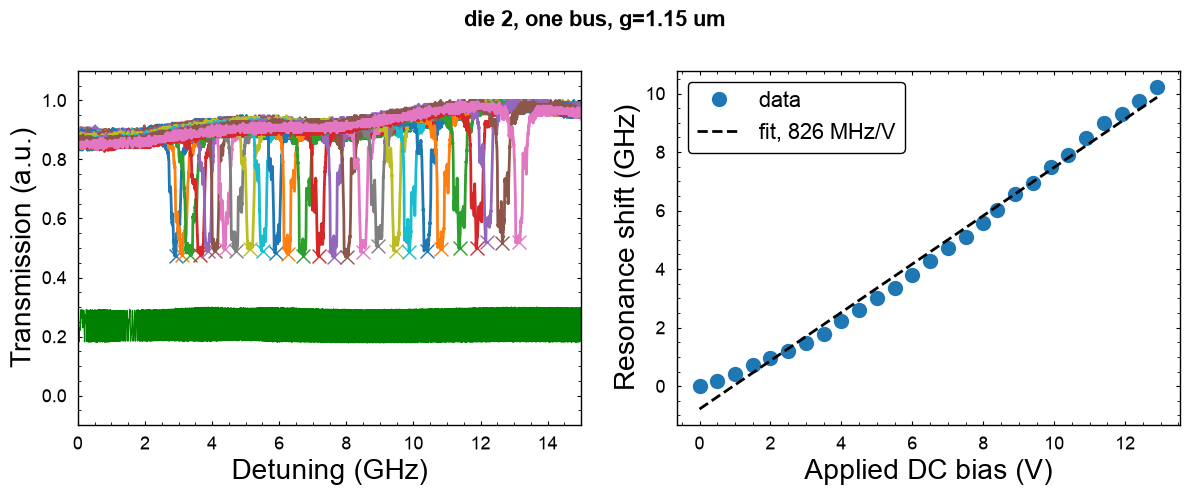

In [8]:

debug = False
include_split = False

smooth_val = 25

MZI_FSR = 24.8 # MHz

base_path = fig2f_join('die2', 'DC_tune_add_thru_run1')
filenames = fig2f_csv_names('die2', 'DC_tune_add_thru_run1')

# Sort filenames by the voltage at the end of the string
filenames.sort(key=lambda x: float(x.split('_')[-1][:-5].replace('p', '.')))

res_freq_vals = []
PZT_voltages = []

fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # Create side by side subplots
fig.suptitle('die 2, one bus, g=1.15 um', fontsize=16)

for filename in filenames:
    voltage = float(filename.split('_')[-1][:-5].replace('p', '.'))
    PZT_voltages.append(voltage)
    path = os.path.join(base_path, filename)
        
    df = pd.read_csv(path)
    start_idx = 0
    end_idx = -1
    df = df[start_idx:end_idx]
    
    Nmean = 1
    y_res = df['trans_pd'].to_numpy()
    y_res = moving_average(y_res, Nmean)  # moving average
    y_res = y_res/np.max(y_res) # normalized data

    y_mzi = df['mzi_pd'].to_numpy()
    y_mzi = moving_average(y_mzi, Nmean)  # moving average
    y_mzi = y_mzi / np.max(y_mzi)*0.2  # normalized data

    freq = calibrate_mzi(y_mzi, fsr_mzi = MZI_FSR, Nmean = 3, Nbetween = 10, peaks_debug = debug) 

    q_data = q_fit_lz(freq, y_res, y_mzi, fsr_mzi=MZI_FSR, lw_guess = [10,10], 
                      wl_res = 780e-9, fit_model=0, add_drop=False, wg_ng = 1.48, fit_plot=False, print_result=False)

    freq = freq - freq[0]
    
    res_resample = q_data['y res']
    mzi_resample = q_data['y mzi']
    y_fit = q_data['y fit']
    
    peak_position = freq[np.argmin(y_fit)]
    res_freq_vals.append(peak_position)
    
    if voltage==0:
        axs[0].plot(freq/1e3, moving_average(q_data['y mzi'],1) * 1 + 0.1, '-g', linewidth=1, label='MZI')
    
    transmission_to_plot = normalize(res_resample)
    axs[0].plot(freq/1e3, transmission_to_plot, linewidth=2)
    axs[0].scatter(peak_position/1e3, transmission_to_plot[np.argmin(res_resample)], marker='x')

axs[0].set_xlabel('Detuning (GHz)', fontsize=20)
axs[0].set_ylabel('Transmission (a.u.)', fontsize=20)
axs[0].set_ylim([-0.1,1.1])
axs[0].set_xlim([0, 15])


PZT_voltages = np.asarray(PZT_voltages)

res_shift = res_freq_vals - res_freq_vals[0]
m, b = linear_fit(PZT_voltages, res_shift)
axs[1].plot(PZT_voltages, (res_freq_vals - res_freq_vals[0])/1e3,'o', label='data')
axs[1].plot(PZT_voltages, (m*PZT_voltages + b)/1e3,'--', lw=2, color='k', label=f'fit, {m:.0f} MHz/V')
axs[1].set_xlabel('Applied DC bias (V)', fontsize=20)
axs[1].set_ylabel('Resonance shift (GHz)', fontsize=20)
axs[1].legend(fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the title
plt.show()


#### Die 3

##### Q-measure

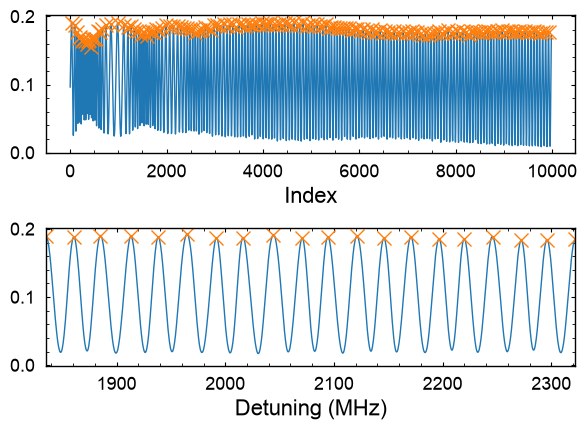

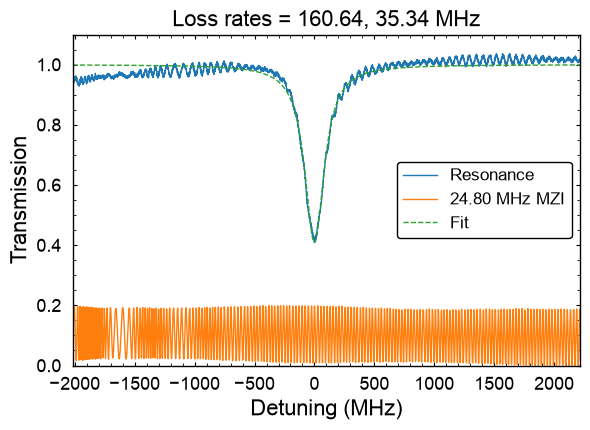

-----------Q Analysis------------
Loss rates = 160.64 , 35.34 MHz
Total loss rate = 195.98 MHz
Intrinsic Q = 2.39 10.88 M
Loaded Q = 1.96 M
Splitting 2g = 0.00 MHz
Propagation loss = 21.68,4.77 dB/m
ER = 3.89 dB


In [9]:
base_path = fig2f_join('die3')
filename = 'Qmeasure_Die3_1ring_1bus_d6_1p15um_gap_MZIFSR_24p8MHz_780p16nm_run1.csv'
path = os.path.join(base_path, filename)

mzi_fsr = 24.8 # MHz

wg_ng = 1.4837

y_res, y_mzi = crop_rescale_res_mzi(path, X_window = 0, Nmean = 3, mzi_debug = False)
f = calibrate_mzi(y_mzi, fsr_mzi = mzi_fsr, Nmean = 15, Nbetween = 10, peaks_debug = True)
q_data = q_fit_lz(f, y_res, y_mzi, fsr_mzi=mzi_fsr, lw_guess = [100, 100], fit_model= 0, add_drop=False, wl_res = 780e-9, wg_ng = wg_ng, fit_plot=True)


##### DC tuning

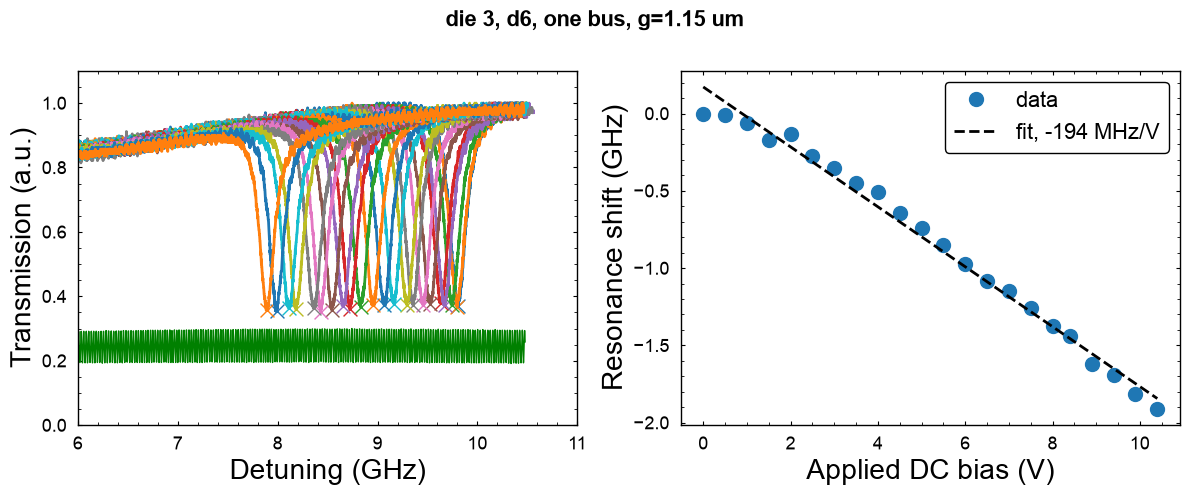

In [38]:
debug = False
include_split = False

smooth_val = 25

MZI_FSR = 24.8 # MHz

base_path = fig2f_join('die3', 'DC_tune_run2')
filenames = fig2f_csv_names('die3', 'DC_tune_run2')

# Sort filenames by the voltage at the end of the string
filenames.sort(key=lambda x: float(x.split('_')[-1][:-5].replace('p', '.')))

res_freq_vals = []
PZT_voltages = []

fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # Create side by side subplots
fig.suptitle('die 3, d6, one bus, g=1.15 um', fontsize=16)

for filename in filenames:
    voltage = float(filename.split('_')[-1][:-5].replace('p', '.'))
    PZT_voltages.append(voltage)
    path = os.path.join(base_path, filename)
        
    df = pd.read_csv(path)
    start_idx = 0
    end_idx = -1
    df = df[start_idx:end_idx]
    
    Nmean = 1
    y_res = df['trans_pd'].to_numpy()
    y_res = moving_average(y_res, Nmean)  # moving average
    y_res = y_res/np.max(y_res) # normalized data

    y_mzi = df['mzi_pd'].to_numpy()
    y_mzi = moving_average(y_mzi, Nmean)  # moving average
    y_mzi = y_mzi / np.max(y_mzi)*0.2  # normalized data

    freq = calibrate_mzi(y_mzi, fsr_mzi = MZI_FSR, Nmean = 3, Nbetween = 10, peaks_debug = debug) 

    q_data = q_fit_lz(freq, y_res, y_mzi, fsr_mzi=MZI_FSR, lw_guess = [10,10], 
                      wl_res = 780e-9, fit_model=0, add_drop=False, wg_ng = 1.48, fit_plot=False, print_result=False)

    freq = freq - freq[0]
    
    res_resample = q_data['y res']
    mzi_resample = q_data['y mzi']
    y_fit = q_data['y fit']
    
    peak_position = freq[np.argmin(y_fit)]
    res_freq_vals.append(peak_position)
    
    if voltage==0:
        axs[0].plot(freq/1e3, moving_average(q_data['y mzi'],1) * 1 + 0.1, '-g', linewidth=1, label='MZI')
    
    transmission_to_plot = normalize(res_resample)
    axs[0].plot(freq/1e3, transmission_to_plot, linewidth=2)
    axs[0].scatter(peak_position/1e3, transmission_to_plot[np.argmin(res_resample)], marker='x')

axs[0].set_xlabel('Detuning (GHz)', fontsize=20)
axs[0].set_ylabel('Transmission (a.u.)', fontsize=20)
axs[0].set_ylim([0,1.1])
axs[0].set_xlim([6, 11])


PZT_voltages = np.asarray(PZT_voltages)

res_shift = res_freq_vals - res_freq_vals[0]
m, b = linear_fit(PZT_voltages, res_shift)
axs[1].plot(PZT_voltages, (res_freq_vals - res_freq_vals[0])/1e3,'o', label='data')
axs[1].plot(PZT_voltages, (m*PZT_voltages + b)/1e3,'--', lw=2, color='k', label=f'fit, {m:.0f} MHz/V')
axs[1].set_xlabel('Applied DC bias (V)', fontsize=20)
axs[1].set_ylabel('Resonance shift (GHz)', fontsize=20)
axs[1].legend(fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the title
plt.show()


#### Die 4

##### Q-measure

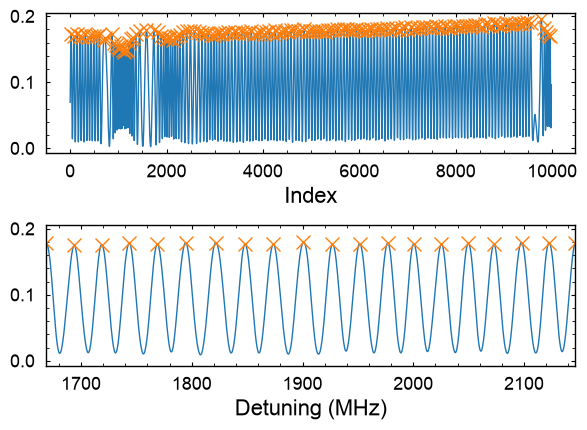

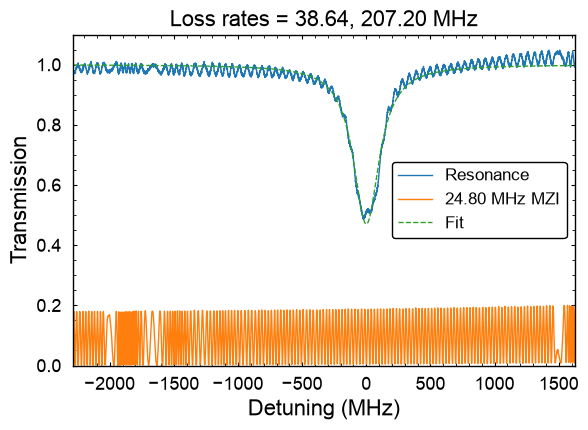

-----------Q Analysis------------
Loss rates = 38.64 , 207.20 MHz
Total loss rate = 245.83 MHz
Intrinsic Q = 9.95 1.86 M
Loaded Q = 1.56 M
Splitting 2g = 0.00 MHz
Propagation loss = 5.21,27.96 dB/m
ER = 3.28 dB


In [11]:
base_path = fig2f_join('die4')
filename = 'Qmeasure_Die4_1ring_1bus_d6_1p15um_gap_MZIFSR_24p8MHz_run2.csv'
path = os.path.join(base_path, filename)

mzi_fsr = 24.8 # MHz

wg_ng = 1.4837

y_res, y_mzi = crop_rescale_res_mzi(path, X_window = 0, Nmean = 3, mzi_debug = False)
f = calibrate_mzi(y_mzi, fsr_mzi = mzi_fsr, Nmean = 15, Nbetween = 10, peaks_debug = True)
q_data = q_fit_lz(f, y_res, y_mzi, fsr_mzi=mzi_fsr, lw_guess = [10, 100], fit_model= 0, add_drop=False, wl_res = 780e-9, wg_ng = wg_ng, fit_plot=True)


##### DC tuning

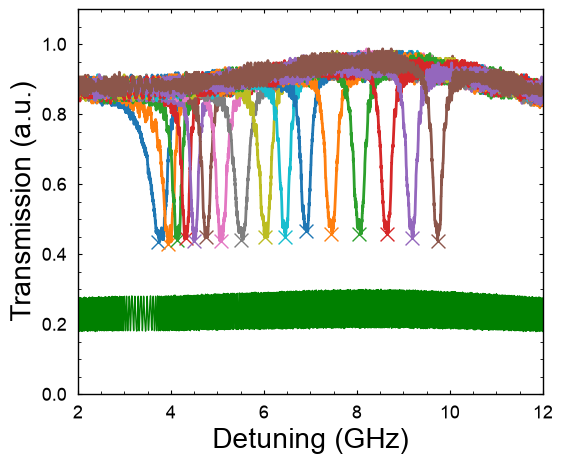

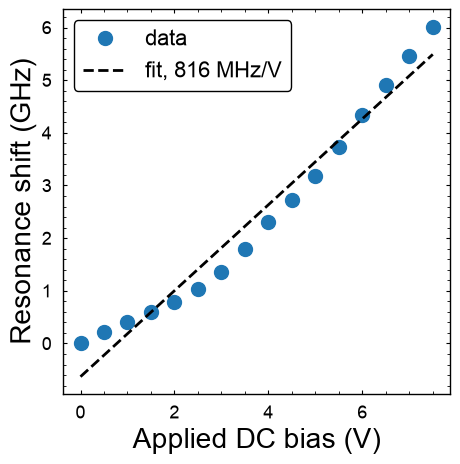

In [40]:
debug = False
include_split = False

smooth_val = 25

MZI_FSR = 24.8 # MHz

base_path = fig2f_join('die4', 'DC_tune_run1')
filenames = fig2f_csv_names('die4', 'DC_tune_run1')

# Sort filenames by the voltage at the end of the string
filenames.sort(key=lambda x: float(x.split('_')[-1][:-5].replace('p', '.')))
filenames
plt.figure(figsize=(6,5))

res_freq_vals = []
PZT_voltages = []
for filename in filenames: 
    voltage = float(filename.split('_')[-1][:-5].replace('p', '.'))
    PZT_voltages.append(voltage)
    path = os.path.join(base_path, filename)
        
    df = pd.read_csv(path)
    start_idx = 100
    end_idx = -300
    df = df[start_idx:end_idx]
    
    Nmean = 1
    y_res = df['trans_pd'].to_numpy()
    y_res = moving_average(y_res, Nmean)  # moving average
    y_res = y_res/np.max(y_res) # normalized data
    
    y_mzi = df['mzi_pd'].to_numpy()
    y_mzi = moving_average(y_mzi, Nmean)  # moving average
    y_mzi = y_mzi / np.max(y_mzi)*0.2  # normalized data
    freq = calibrate_mzi(y_mzi, fsr_mzi = MZI_FSR, Nmean = 4, Nbetween = 6, peaks_debug = False) 

    q_data = q_fit_lz(freq, y_res, y_mzi, fsr_mzi=MZI_FSR, lw_guess = [10,10], 
                    wl_res = 780e-9, fit_model=0, add_drop=False, wg_ng = 1.48, fit_plot=False, print_result=False)

    freq = freq - freq[0]
    
    res_resample = q_data['y res']
    mzi_resample = q_data['y mzi']
    y_fit = q_data['y fit']
    
    peak_position = freq[np.argmin(y_fit)]
    res_freq_vals.append(peak_position)
        
    if voltage==0:
        plt.plot(freq/1e3, moving_average(q_data['y mzi'],1) * 1 + 0.1, '-g', linewidth=1, label='MZI')
    
    transmission_to_plot = normalize(res_resample)
    plt.plot(freq/1e3, transmission_to_plot, linewidth=2)#, label=f'PZT = {voltage:.1f} V')
    plt.scatter(peak_position/1e3, transmission_to_plot[np.argmin(res_resample)], marker='x')

plt.xlabel('Detuning (GHz)', fontsize=20)
plt.ylabel('Transmission (a.u.)', fontsize=20)
plt.ylim([0,1.1])
plt.xlim([2, 12])
plt.show()


PZT_voltages = np.asarray(PZT_voltages)

res_shift = res_freq_vals - res_freq_vals[0]
m, b = linear_fit(PZT_voltages, res_shift)
plt.figure(figsize=(5,5))
plt.plot(PZT_voltages, (res_freq_vals - res_freq_vals[0])/1e3,'o', label='data')
plt.plot(PZT_voltages, (m*PZT_voltages + b)/1e3,'--', lw=2, color='k', label=f'fit, {m:.0f} MHz/V')
plt.xlabel('Applied DC bias (V)', fontsize=20)
plt.ylabel('Resonance shift (GHz)', fontsize=20)
plt.legend(fontsize=16)
plt.show()


#### Die 7

##### Q-measure

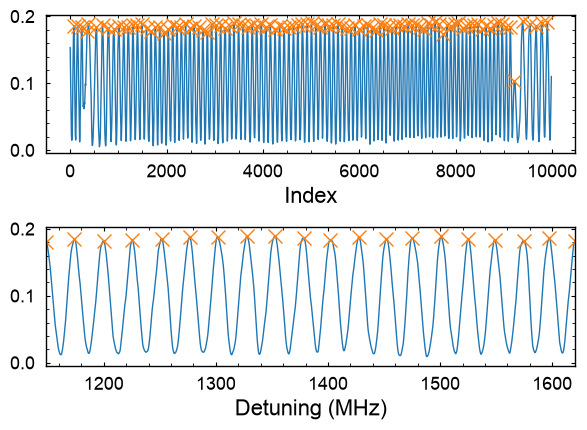

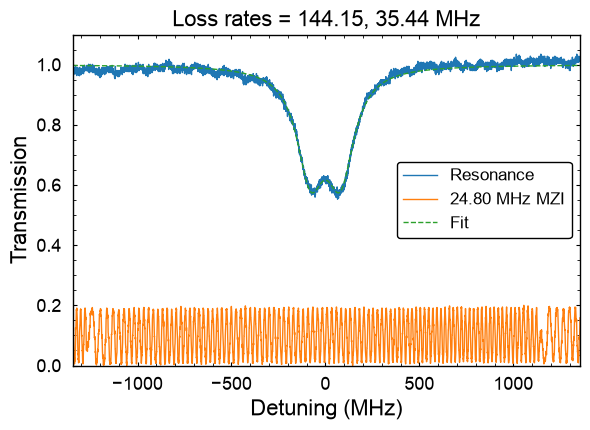

-----------Q Analysis------------
Loss rates = 144.15 , 35.44 MHz
Total loss rate = 179.59 MHz
Intrinsic Q = 2.67 10.85 M
Loaded Q = 2.14 M
Splitting 2g = -128.90 MHz
Propagation loss = 19.45,4.78 dB/m
ER = 2.41 dB


In [13]:
base_path = fig2f_join('die7')
filename = 'Die7_1ring_1bus_d6_1p15um_gap_MZIFSR_24MHz_PZT_0p0V.csv'
path = os.path.join(base_path, filename)

mzi_fsr = 24.8 # MHz

wg_ng = 1.4837

y_res, y_mzi = crop_rescale_res_mzi(path, X_window = 0, Nmean = 3, mzi_debug = False)
f = calibrate_mzi(y_mzi, fsr_mzi = mzi_fsr, Nmean = 15, Nbetween = 10, peaks_debug = True)
q_data = q_fit_lz(f, y_res, y_mzi, fsr_mzi=mzi_fsr, lw_guess = [100, 100,10], fit_model= 1, add_drop=False, wl_res = 780e-9, wg_ng = wg_ng, fit_plot=True)


##### DC tuning

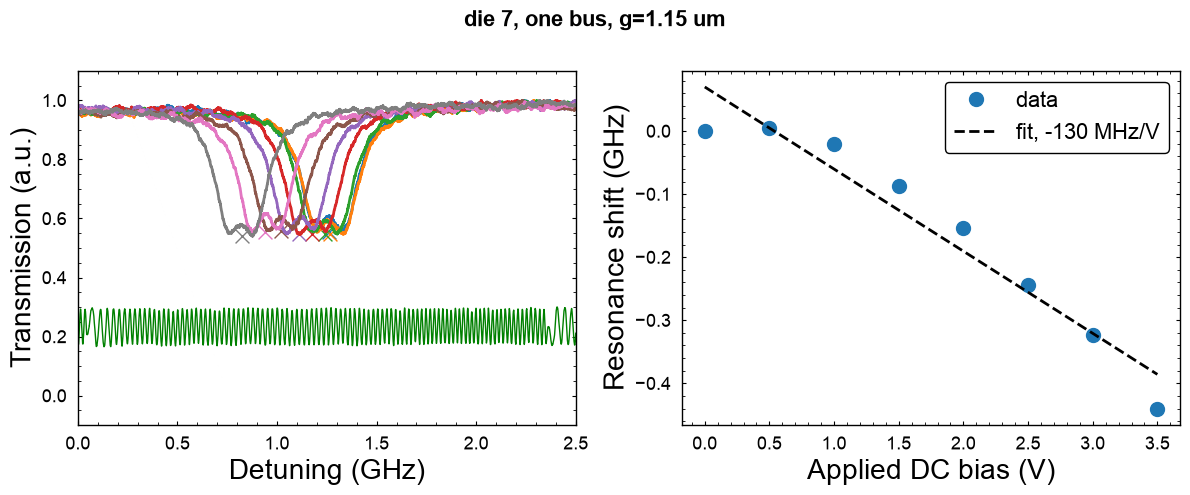

In [14]:
debug = False
include_split = False

smooth_val = 25

MZI_FSR = 24 # MHz

base_path = fig2f_join('die7')
filenames = fig2f_csv_names('die7')

# Sort filenames by the voltage at the end of the string
filenames.sort(key=lambda x: float(x.split('_')[-1][:-5].replace('p', '.')))

res_freq_vals = []
PZT_voltages = []

fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # Create side by side subplots
fig.suptitle('die 7, one bus, g=1.15 um', fontsize=16)

for filename in filenames:
    voltage = float(filename.split('_')[-1][:-5].replace('p', '.'))
    PZT_voltages.append(voltage)
    path = os.path.join(base_path, filename)
        
    df = pd.read_csv(path)
    start_idx = 100
    end_idx = -100
    df = df[start_idx:end_idx]
    
    Nmean = 20
    y_res = df['trans_pd'].to_numpy()
    y_res = moving_average(y_res, Nmean)  # moving average
    y_res = y_res/np.max(y_res) # normalized data

    y_mzi = df['mzi_pd'].to_numpy()
    y_mzi = moving_average(y_mzi, Nmean)  # moving average
    y_mzi = y_mzi / np.max(y_mzi)*0.2  # normalized data

    freq = calibrate_mzi(y_mzi, fsr_mzi = MZI_FSR, Nmean = 15, Nbetween = 50, peaks_debug = debug)

    q_data = q_fit_lz(freq, y_res, y_mzi, fsr_mzi=MZI_FSR, lw_guess = [100, 100.0], 
                        wl_res = 780e-9, fit_model=0, add_drop=False, wg_ng = 1.48, fit_plot=False, print_result=False)

    freq = freq - freq[0]
    
    res_resample = q_data['y res']
    mzi_resample = q_data['y mzi']
    y_fit = q_data['y fit']
    
    peak_position = freq[np.argmin(y_fit)]
    res_freq_vals.append(peak_position)
    
    if voltage==0:
        axs[0].plot(freq/1e3, moving_average(q_data['y mzi'],1) * 1 + 0.1, '-g', linewidth=1, label='MZI')
    
    transmission_to_plot = normalize(res_resample)
    axs[0].plot(freq/1e3, transmission_to_plot, linewidth=2)
    axs[0].scatter(peak_position/1e3, transmission_to_plot[np.argmin(res_resample)], marker='x')

axs[0].set_xlabel('Detuning (GHz)', fontsize=20)
axs[0].set_ylabel('Transmission (a.u.)', fontsize=20)
axs[0].set_ylim([-0.1,1.1])
axs[0].set_xlim([0, 2.5])


PZT_voltages = np.asarray(PZT_voltages)
res_shift = res_freq_vals - res_freq_vals[0]
m, b = linear_fit(PZT_voltages, res_shift)
axs[1].plot(PZT_voltages, (res_freq_vals - res_freq_vals[0])/1e3,'o', label='data')
axs[1].plot(PZT_voltages, (m*PZT_voltages + b)/1e3,'--', lw=2, color='k', label=f'fit, {m:.0f} MHz/V')
axs[1].set_xlabel('Applied DC bias (V)', fontsize=20)
axs[1].set_ylabel('Resonance shift (GHz)', fontsize=20)
axs[1].legend(fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the title
plt.show()


#### Die 8

##### Q-measure

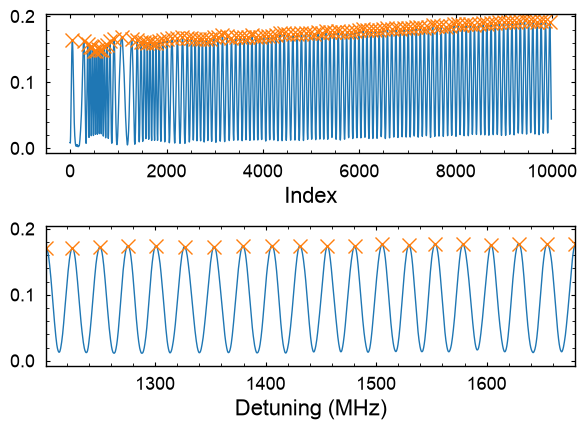

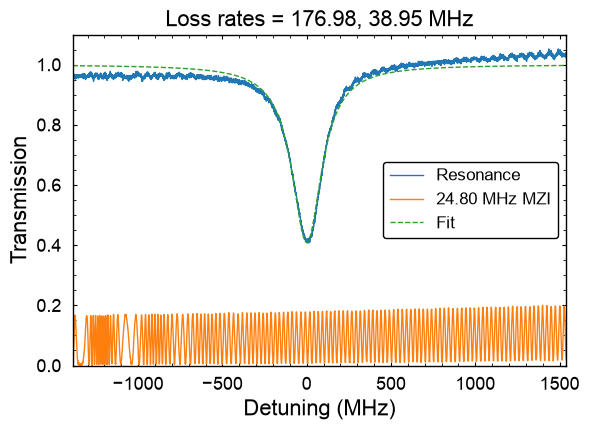

-----------Q Analysis------------
Loss rates = 176.98 , 38.95 MHz
Total loss rate = 215.93 MHz
Intrinsic Q = 2.17 9.87 M
Loaded Q = 1.78 M
Splitting 2g = 0.00 MHz
Propagation loss = 23.88,5.26 dB/m
ER = 3.89 dB


In [15]:
base_path = fig2f_join('die8')
filename = 'Qmeasure_Die8_1ring_1bus_1p15um_gap_MZIFSR_24p8MHz_780p24nm_non_split_res.csv'
path = os.path.join(base_path, filename)

mzi_fsr = 24.8 # MHz

wg_ng = 1.4837

y_res, y_mzi = crop_rescale_res_mzi(path, X_window = 0, Nmean = 3, mzi_debug = False)
f = calibrate_mzi(y_mzi, fsr_mzi = mzi_fsr, Nmean = 15, Nbetween = 10, peaks_debug = True)
q_data = q_fit_lz(f, y_res, y_mzi, fsr_mzi=mzi_fsr, lw_guess = [100, 100], fit_model= 0, add_drop=False, wl_res = 780e-9, wg_ng = wg_ng, fit_plot=True)


##### DC tuning

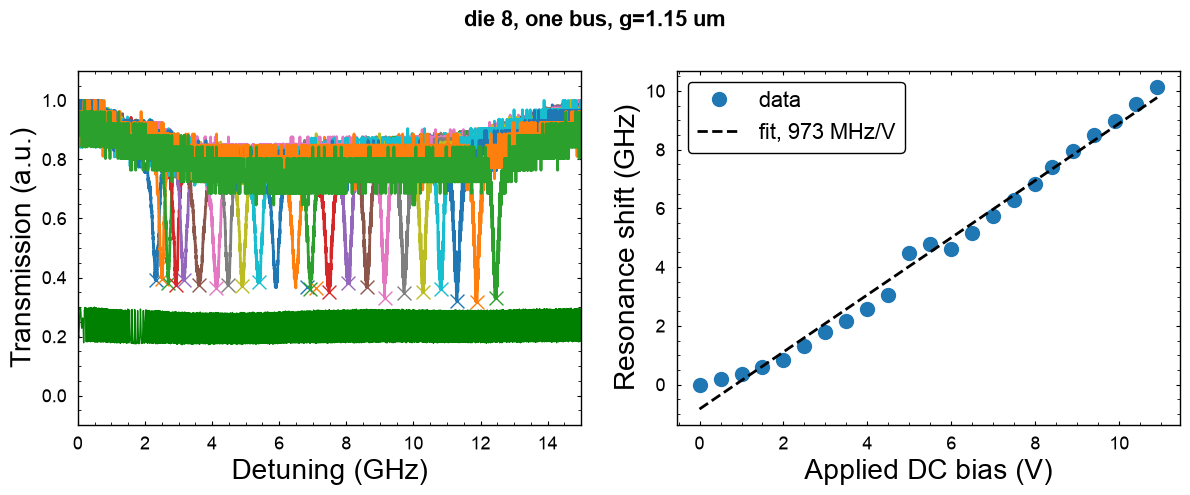

In [16]:
debug = False
include_split = False

smooth_val = 25

MZI_FSR = 24.8 # MHz

base_path = fig2f_join('die8', 'DC_tune_add_thru_run1')
filenames = fig2f_csv_names('die8', 'DC_tune_add_thru_run1')

# Sort filenames by the voltage at the end of the string
filenames.sort(key=lambda x: float(x.split('_')[-1][:-5].replace('p', '.')))

res_freq_vals = []
PZT_voltages = []

fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # Create side by side subplots
fig.suptitle('die 8, one bus, g=1.15 um', fontsize=16)

for filename in filenames:
    voltage = float(filename.split('_')[-1][:-5].replace('p', '.'))
    PZT_voltages.append(voltage)
    path = os.path.join(base_path, filename)
        
    df = pd.read_csv(path)
    start_idx = 0
    end_idx = -1
    df = df[start_idx:end_idx]
    
    Nmean = 1
    y_res = df['trans_pd'].to_numpy()
    y_res = moving_average(y_res, Nmean)  # moving average
    y_res = y_res/np.max(y_res) # normalized data

    y_mzi = df['mzi_pd'].to_numpy()
    y_mzi = moving_average(y_mzi, Nmean)  # moving average
    y_mzi = y_mzi / np.max(y_mzi)*0.2  # normalized data

    freq = calibrate_mzi(y_mzi, fsr_mzi = MZI_FSR, Nmean = 3, Nbetween = 10, peaks_debug = debug) 

    q_data = q_fit_lz(freq, y_res, y_mzi, fsr_mzi=MZI_FSR, lw_guess = [10,10], 
                      wl_res = 780e-9, fit_model=0, add_drop=True, wg_ng = 1.48, fit_plot=False, print_result=False)

    freq = freq - freq[0]
    
    res_resample = q_data['y res']
    mzi_resample = q_data['y mzi']
    y_fit = q_data['y fit']
    
    peak_position = freq[np.argmin(y_fit)]
    res_freq_vals.append(peak_position)
    
    if voltage==0:
        axs[0].plot(freq/1e3, moving_average(q_data['y mzi'],1) * 1 + 0.1, '-g', linewidth=1, label='MZI')
    
    transmission_to_plot = normalize(res_resample)
    axs[0].plot(freq/1e3, transmission_to_plot, linewidth=2)
    axs[0].scatter(peak_position/1e3, transmission_to_plot[np.argmin(res_resample)], marker='x')

axs[0].set_xlabel('Detuning (GHz)', fontsize=20)
axs[0].set_ylabel('Transmission (a.u.)', fontsize=20)
axs[0].set_ylim([-0.1,1.1])
axs[0].set_xlim([0, 15])


PZT_voltages = np.asarray(PZT_voltages)

res_shift = res_freq_vals - res_freq_vals[0]
m, b = linear_fit(PZT_voltages, res_shift)
axs[1].plot(PZT_voltages, (res_freq_vals - res_freq_vals[0])/1e3,'o', label='data')
axs[1].plot(PZT_voltages, (m*PZT_voltages + b)/1e3,'--', lw=2, color='k', label=f'fit, {m:.0f} MHz/V')
axs[1].set_xlabel('Applied DC bias (V)', fontsize=20)
axs[1].set_ylabel('Resonance shift (GHz)', fontsize=20)
axs[1].legend(fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the title
plt.show()


#### Die 10

##### Q-measure

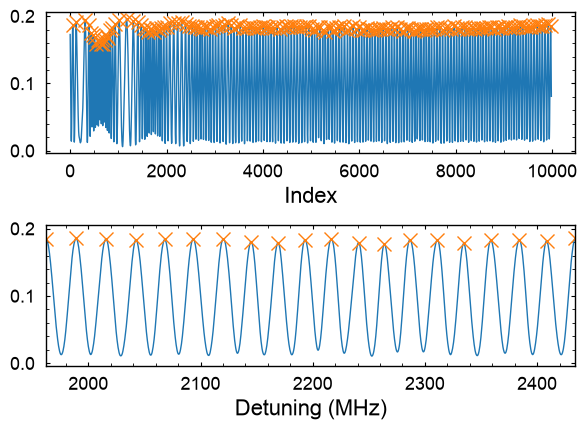

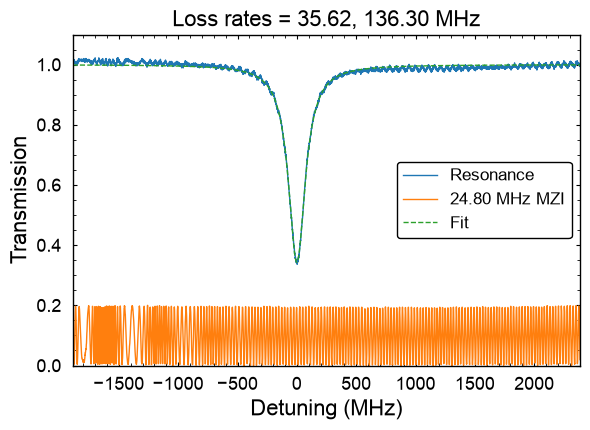

-----------Q Analysis------------
Loss rates = 35.62 , 136.30 MHz
Total loss rate = 171.92 MHz
Intrinsic Q = 10.79 2.82 M
Loaded Q = 2.24 M
Splitting 2g = 0.00 MHz
Propagation loss = 4.81,18.39 dB/m
ER = 4.65 dB


In [17]:
base_path = fig2f_join('die10')
filename = 'Qmeasure_Die10_1ring_1bus_1p15um_gap_MZIFSR_24p8MHz_780p16nm_non_split_res.csv'
path = os.path.join(base_path, filename)

mzi_fsr = 24.8 # MHz

wg_ng = 1.4837

y_res, y_mzi = crop_rescale_res_mzi(path, X_window = 0, Nmean = 3, mzi_debug = False)
f = calibrate_mzi(y_mzi, fsr_mzi = mzi_fsr, Nmean = 15, Nbetween = 10, peaks_debug = True)
q_data = q_fit_lz(f, y_res, y_mzi, fsr_mzi=mzi_fsr, lw_guess = [100, 100], fit_model= 0, add_drop=False, wl_res = 780e-9, wg_ng = wg_ng, fit_plot=True)




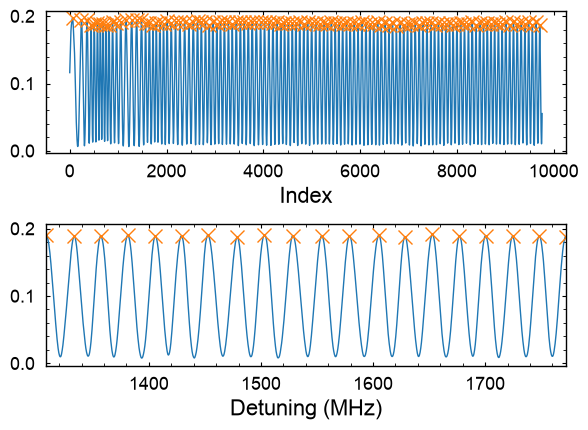

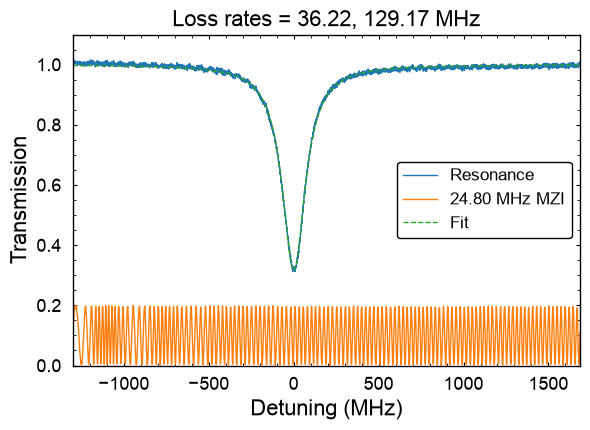

-----------Q Analysis------------
Loss rates = 36.22 , 129.17 MHz
Total loss rate = 165.39 MHz
Intrinsic Q = 10.61 2.98 M
Loaded Q = 2.32 M
Splitting 2g = 0.00 MHz
Propagation loss = 4.89,17.43 dB/m
ER = 5.01 dB


In [18]:
base_path = fig2f_join('die10')
filename = 'Qmeasure_Die10_1ring_1bus_1p15um_gap_MZIFSR_24p8MHz_780p18nm_non_split_res.csv'
path = os.path.join(base_path, filename)

mzi_fsr = 24.8 # MHz

wg_ng = 1.4837

y_res, y_mzi = crop_rescale_res_mzi(path, X_window = 0, Nmean = 3, mzi_debug = False)
f = calibrate_mzi(y_mzi, fsr_mzi = mzi_fsr, Nmean = 15, Nbetween = 10, peaks_debug = True)
q_data = q_fit_lz(f, y_res, y_mzi, fsr_mzi=mzi_fsr, lw_guess = [100, 100], fit_model= 0, add_drop=False, wl_res = 780e-9, wg_ng = wg_ng, fit_plot=True)


##### DC tuning

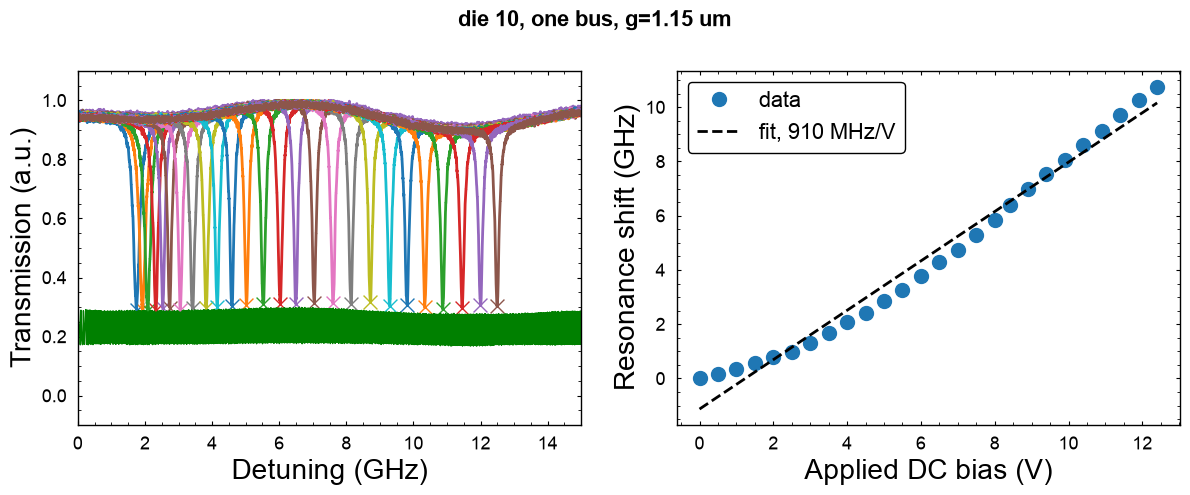

In [19]:
debug = False
include_split = False

smooth_val = 25

MZI_FSR = 24.8 # MHz

base_path = fig2f_join('die10', 'DC_tune_add_thru_run1')
filenames = fig2f_csv_names('die10', 'DC_tune_add_thru_run1')

# Sort filenames by the voltage at the end of the string
filenames.sort(key=lambda x: float(x.split('_')[-1][:-5].replace('p', '.')))

res_freq_vals = []
PZT_voltages = []

fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # Create side by side subplots
fig.suptitle('die 10, one bus, g=1.15 um', fontsize=16)

for filename in filenames:
    voltage = float(filename.split('_')[-1][:-5].replace('p', '.'))
    PZT_voltages.append(voltage)
    path = os.path.join(base_path, filename)
        
    df = pd.read_csv(path)
    start_idx = 0
    end_idx = -1
    df = df[start_idx:end_idx]
    
    Nmean = 3
    y_res = df['trans_pd'].to_numpy()
    y_res = moving_average(y_res, Nmean)  # moving average
    y_res = y_res/np.max(y_res) # normalized data

    y_mzi = df['mzi_pd'].to_numpy()
    y_mzi = moving_average(y_mzi, Nmean)  # moving average
    y_mzi = y_mzi / np.max(y_mzi)*0.2  # normalized data

    freq = calibrate_mzi(y_mzi, fsr_mzi = MZI_FSR, Nmean = 3, Nbetween = 10, peaks_debug = debug) 

    q_data = q_fit_lz(freq, y_res, y_mzi, fsr_mzi=MZI_FSR, lw_guess = [100,100], 
                      wl_res = 780e-9, fit_model=0, add_drop=False, wg_ng = 1.48, fit_plot=False, print_result=False)

    freq = freq - freq[0]
    
    res_resample = q_data['y res']
    mzi_resample = q_data['y mzi']
    y_fit = q_data['y fit']
    
    peak_position = freq[np.argmin(y_fit)]
    res_freq_vals.append(peak_position)
    
    if voltage==0:
        axs[0].plot(freq/1e3, moving_average(q_data['y mzi'],1) * 1 + 0.1, '-g', linewidth=1, label='MZI')
    
    transmission_to_plot = normalize(res_resample)
    axs[0].plot(freq/1e3, transmission_to_plot, linewidth=2)
    axs[0].scatter(peak_position/1e3, transmission_to_plot[np.argmin(res_resample)], marker='x')

axs[0].set_xlabel('Detuning (GHz)', fontsize=20)
axs[0].set_ylabel('Transmission (a.u.)', fontsize=20)
axs[0].set_ylim([-0.1,1.1])
axs[0].set_xlim([0, 15])


PZT_voltages = np.asarray(PZT_voltages)

res_shift = res_freq_vals - res_freq_vals[0]
m, b = linear_fit(PZT_voltages, res_shift)
axs[1].plot(PZT_voltages, (res_freq_vals - res_freq_vals[0])/1e3,'o', label='data')
axs[1].plot(PZT_voltages, (m*PZT_voltages + b)/1e3,'--', lw=2, color='k', label=f'fit, {m:.0f} MHz/V')
axs[1].set_xlabel('Applied DC bias (V)', fontsize=20)
axs[1].set_ylabel('Resonance shift (GHz)', fontsize=20)
axs[1].legend(fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the title
plt.show()


## Figure 4

TOF thermometry for Rb-87 MOT expansion with propagated Gaussian-fit error bars.

Each point is extracted from a 10-shot accumulated fluorescence image. 
Vertical error bars represent the propagated Gaussian-fit uncertainty in σ^2, 
including a one-pixel extraction floor. Temperatures are obtained from 
weighted fits to:
σ^2(t)=σ_0^2+(k_BT/m)t^2. 
 
The quoted temperature uncertainties include
the fit/extraction uncertainty and the systematic uncertainty from the imaging
calibration, 12.86±0.26 μm/pixel (2% error), added in quadrature.


Expected layout:

WORK_DIR/                     <-- the folder you are running this script in
    figure4/                  <-- FIGURE 4 directory (should be here already)
        Case I/
            1_0ms.tiff
            2_0ms.tiff
            3_0ms.tiff
            4_0ms.tiff
            5_0ms.tiff
            6_0ms.tiff
        Case II/
            ... same six files
        Case III/
            ... same six files
        Case IV/
            ... same six files


In [20]:
%matplotlib inline

import os
import re
import numpy as np
import math

import matplotlib.pyplot as plt
import tifffile as tiff
from scipy.ndimage import uniform_filter
from scipy.optimize import curve_fit
from scipy.constants import Boltzmann as kB

def _show(final=False):
    """
    Display figures. Under the inline backend each figure stays in the
    output cell that produced it, so no blocking call is needed.
    """
    plt.show()


# Rb-87 atomic mass (kg)
M_RB87 = 1.443160648e-25


def apply_collaborator_style():
    """
    Collaborator's preferred rcParams. Appearance only; the analysis is
    unaffected.
    """
    import matplotlib as mpl
    from cycler import cycler

    mpl.rcParams.update({
        # Figure
        'figure.figsize': (6, 4.4),
        'figure.facecolor': 'white',
        'figure.dpi': 100,
        'figure.titleweight': 'bold',

        # Saving
        'savefig.dpi': 300,
        'savefig.facecolor': 'white',
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1,
        'savefig.format': 'svg',

        # Fonts
        'font.family': 'Arial',
        'font.style': 'normal',

        # Axes
        'axes.grid': False,
        'axes.titlesize': 16,
        'axes.labelsize': 16,
        'axes.linewidth': 1,
        'axes.prop_cycle': cycler('color', [
            '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
            '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
            '#bcbd22', '#17becf'
        ]),

        # Tick labels
        'xtick.labelsize': 13,
        'ytick.labelsize': 13,
        'xtick.top': True,
        'ytick.right': True,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.minor.visible': True,
        'ytick.minor.visible': True,
        'xtick.major.size': 3,
        'ytick.major.size': 3,
        'xtick.minor.size': 2,
        'ytick.minor.size': 2,
        'xtick.major.pad': 8,
        'ytick.major.pad': 8,

        # Legend
        'legend.frameon': True,
        'legend.framealpha': 1,
        'legend.facecolor': 'white',
        'legend.edgecolor': 'black',
        'legend.shadow': False,
        'legend.fontsize': 12,

        # Lines
        'lines.linewidth': 1,
        'lines.markersize': 10,
    })

In [21]:
import os

WORK_DIR = os.getcwd()
# WORK_DIR = r"C:\Users\Lab202\Box\Graduate School\Papers\Agile optical resonator\Uncertainty calculations"

FIGURE_DIR = "figure4"

DATA_DIR = os.path.join(WORK_DIR, FIGURE_DIR)

case_paths = {
    case: os.path.join(DATA_DIR, f"Case {case}")
    for case in ["I", "II", "III", "IV"]
}

print(f"DATA_DIR {'found' if os.path.isdir(DATA_DIR) else 'MISSING':<8} {DATA_DIR}\n")
for case, path in case_paths.items():
    ok = os.path.isdir(path)
    n = len([f for f in os.listdir(path) if f.lower().endswith((".tif", ".tiff"))]) if ok else 0
    print(f"  Case {case:<4} {'found' if ok else 'MISSING':<8} {n} tiff  {path}")

DATA_DIR found    /Users/andrei/code/ocpi/papers/ncomms2026-780pzt/figure4

  Case I    found    6 tiff  /Users/andrei/code/ocpi/papers/ncomms2026-780pzt/figure4/Case I
  Case II   found    6 tiff  /Users/andrei/code/ocpi/papers/ncomms2026-780pzt/figure4/Case II
  Case III  found    6 tiff  /Users/andrei/code/ocpi/papers/ncomms2026-780pzt/figure4/Case III
  Case IV   found    15 tiff  /Users/andrei/code/ocpi/papers/ncomms2026-780pzt/figure4/Case IV


Helpers

In [22]:
def sigmacalc(hwhm):
    """
    Convert half-width at half max to Gaussian sigma.
    """
    sigma = hwhm / np.sqrt(2 * math.log(2))
    return sigma


def HWHM(sigma):
    """
    Convert Gaussian sigma to half-width at half max.
    """
    r = np.sqrt(2 * math.log(2)) * sigma
    return r


_TOF_RE = re.compile(r'^(\d+)(?:_(\d+))?\s*ms$', re.IGNORECASE)


def parse_tof_ms(filename):
    """
    Parse the time of flight in ms from a filename.

    The underscore is read as a decimal point. Accepts an optional
    directory prefix and extension, and both path separators:

        '1_0ms'           -> 1.0
        '2_5ms'           -> 2.5
        '10_25ms.tiff'    -> 10.25
        'C:/x/3ms.tif'    -> 3.0

    Raises ValueError on an unrecognised name rather than silently
    assigning the wrong flight time.
    """
    # os.path.basename only splits backslashes on Windows, so normalise
    # by hand to keep the parse identical across platforms.
    tail = str(filename).replace('\\', '/').rstrip('/').split('/')[-1]
    stem = os.path.splitext(tail)[0]
    m = _TOF_RE.match(stem.strip())
    if m is None:
        raise ValueError(f"Cannot parse TOF from filename: {filename!r}")
    whole, frac = m.groups()
    return float(whole) if frac is None else float(f"{whole}.{frac}")


def import_photos(filenames, base_path, movie_name='TOF_movie.tiff'):
    """
    Import TIFF images into a 3D array with shape:
        arr[image_index, z_pixel, y_pixel]

    Ordered by parsed flight time, not string order.
    """

    image_files = [os.path.join(base_path, f) for f in filenames]

    missing = [p for p in image_files if not os.path.isfile(p)]
    if missing:
        if not os.path.isdir(base_path):
            raise FileNotFoundError(f"base_path does not exist: {base_path!r}")
        raise FileNotFoundError(
            f"{len(missing)} image(s) not found in {base_path!r}.\n"
            f"  missing: {[os.path.basename(p) for p in missing]}\n"
            f"  present: {sorted(os.listdir(base_path))}"
        )

    image_files = sorted(image_files, key=parse_tof_ms)

    images = np.stack([tiff.imread(img) for img in image_files], axis=0)

    return images


def import_flight_times(filenames):
    """
    Extract flight times from filenames.

    Assumes filenames are like:
        '1_0ms', '2_0ms', ...
    or similar, where the number before the first underscore is the TOF in ms.
    """

    sorted_files = sorted(filenames, key=parse_tof_ms)

    flight_times = np.asarray([parse_tof_ms(f) for f in sorted_files])

    if len(np.unique(flight_times)) != len(flight_times):
        raise ValueError(f"Duplicate flight times: {flight_times}")
    if not np.all(np.diff(flight_times) > 0):
        raise ValueError(f"Flight times not sorted: {flight_times}")

    return flight_times

Gaussian fitting of the integrated profiles

In [23]:
def gaussian_1d(x, a, x0, sigma, c):
    """
    1D Gaussian with constant offset.
    """
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + c


def run_gauss_fit(img, axis='y'):
    """
    Fit a 1D Gaussian to the integrated image profile.

    axis='y':
        Sum over z/pixel rows, leaving a profile along y.

    axis='z':
        Sum over y/pixel columns, leaving a profile along z.

    Returns:
        pix           : pixel coordinate array
        signal        : integrated 1D signal
        Gauss         : fitted Gaussian evaluated on pix
        sigma         : fitted Gaussian sigma in pixels
        sigma_err     : 1-sigma uncertainty in sigma from curve_fit covariance
        amp           : fitted amplitude
        amp_idx       : index of max signal
    """

    if axis == 'y':
        sumaxis = 0
        pix_len = img.shape[1]
    elif axis == 'z':
        sumaxis = 1
        pix_len = img.shape[0]
    else:
        raise ValueError("axis must be 'y' or 'z'")

    pix = np.arange(pix_len)

    # Integrated 1D profile.
    signal = np.sum(img, axis=sumaxis)

    # Baseline removal; c is still fit freely on top of this.
    signal = signal - np.min(signal)

    amp_guess = np.max(signal)
    x0_guess = pix[np.argmax(signal)]
    sigma_guess = pix_len / 10
    c_guess = np.min(signal)

    initial_guess = [amp_guess, x0_guess, sigma_guess, c_guess]

    # Bounds help prevent unphysical negative widths.
    lower_bounds = [0, 0, 0, -np.inf]
    upper_bounds = [np.inf, pix_len, np.inf, np.inf]

    popt, pcov = curve_fit(
        gaussian_1d,
        pix,
        signal,
        p0=initial_guess,
        bounds=(lower_bounds, upper_bounds),
        maxfev=10000
    )

    amp, x0, sigma, c = popt

    sigma = abs(sigma)

    # Uncertainty in fitted sigma from covariance matrix.
    # Parameter order is [a, x0, sigma, c], so sigma is index 2.
    if pcov is None or not np.isfinite(pcov[2, 2]) or pcov[2, 2] < 0:
        sigma_err = np.nan
    else:
        sigma_err = np.sqrt(pcov[2, 2])

    Gauss = gaussian_1d(pix, *popt)

    amp_idx = np.argmax(signal)

    return pix, signal, Gauss, sigma, sigma_err, amp, amp_idx

Temp extraction with uncertain prop

In [41]:
def extract_temperature_with_errors(
    tof_ms,
    sigma_um,
    sigma_err_um=None,
    one_pixel_floor_um=None
):
    """
    Fit sigma^2 vs t^2 to extract temperature.

    Model:
        sigma^2(t) = sigma0^2 + slope * t^2

    With:
        slope = kB T / m

    Units:
        tof_ms       : time of flight in ms
        sigma_um     : Gaussian sigma in microns
        sigma_err_um : uncertainty in Gaussian sigma in microns

    Internally:
        sigma is converted to mm
        t remains in ms

    Since:
        mm^2 / ms^2 = m^2 / s^2

    the numerical slope in mm^2/ms^2 is equal to m^2/s^2.
    """

    M_Rb87 = M_RB87

    tof_ms = np.asarray(tof_ms, dtype=float)
    sigma_um = np.asarray(sigma_um, dtype=float)

    t2 = tof_ms**2

    sigma_mm = sigma_um / 1000.0
    sigma2_mm2 = sigma_mm**2

    sigma2_err_mm2 = None

    if sigma_err_um is not None:
        sigma_err_um = np.asarray(sigma_err_um, dtype=float)

        # Add the one-pixel extraction floor in quadrature. Points whose
        # covariance failed get the bare floor instead. The branches are
        # exclusive: applying both would give sqrt(2)*floor. np.where
        # returns a new array, so the caller's input is left intact.
        if one_pixel_floor_um is not None:
            bad = ~np.isfinite(sigma_err_um)
            if np.any(bad):
                print(f"  WARNING: {np.sum(bad)} non-finite sigma fit error(s) "
                      f"at index/indices {np.where(bad)[0]}")
            sigma_err_um = np.where(
                bad,
                one_pixel_floor_um,
                np.sqrt(sigma_err_um**2 + one_pixel_floor_um**2)
            )

        sigma_err_mm = sigma_err_um / 1000.0

        # Propagate y = sigma^2:
        # dy = 2 sigma d_sigma
        sigma2_err_mm2 = 2.0 * sigma_mm * sigma_err_mm

        # Avoid zero or nonfinite weights.
        bad_err = (~np.isfinite(sigma2_err_mm2)) | (sigma2_err_mm2 <= 0)

        if np.any(bad_err):
            if one_pixel_floor_um is not None:
                floor_mm = one_pixel_floor_um / 1000.0
                sigma2_err_mm2[bad_err] = 2.0 * sigma_mm[bad_err] * floor_mm
            else:
                sigma2_err_mm2 = None

    def tof_model(t2_val, sigma0_sq, slope):
        return sigma0_sq + slope * t2_val

    # Weighted fit if errors are available.
    if sigma2_err_mm2 is not None:
        fit_params, fit_cov = curve_fit(
            tof_model,
            t2,
            sigma2_mm2,
            sigma=sigma2_err_mm2,
            absolute_sigma=True
        )
    else:
        fit_params, fit_cov = curve_fit(
            tof_model,
            t2,
            sigma2_mm2
        )

    sigma0_sq, slope = fit_params

    fitted = tof_model(t2, sigma0_sq, slope)

    # Temperature:
    # slope has units mm^2/ms^2, numerically equal to m^2/s^2.
    Temp_uK = 1e6 * slope * M_Rb87 / kB

    # Temperature uncertainty from the slope covariance.
    slope_err = np.sqrt(fit_cov[1, 1])
    Temp_err_uK = 1e6 * slope_err * M_Rb87 / kB

    sigma0_mm = np.sqrt(sigma0_sq) if sigma0_sq > 0 else np.nan

    # absolute_sigma=True takes the error bars at face value, so chi2_red
    # is the check on that. Much above 1 means the bars are too small or
    # the expansion is not ballistic; much below 1 means they are generous.
    dof = len(t2) - 2
    if sigma2_err_mm2 is not None and dof > 0:
        chi2 = float(np.sum(((sigma2_mm2 - fitted) / sigma2_err_mm2)**2))
        chi2_red = chi2 / dof
    else:
        chi2 = np.nan
        chi2_red = np.nan

    return {
        "chi2": chi2,
        "chi2_red": chi2_red,
        "dof": dof,
        "t2": t2,
        "sigma2_mm2": sigma2_mm2,
        "sigma2_err_mm2": sigma2_err_mm2,
        "Temp_uK": Temp_uK,
        "Temp_err_uK": Temp_err_uK,
        "sigma0_sq_mm2": sigma0_sq,
        "sigma0_mm": sigma0_mm,
        "slope": slope,
        "slope_err": slope_err,
        "fitted": fitted,
        "fit_cov": fit_cov
    }

Plotting each case separately:

In [42]:
def plot_t2_r2(
    tof_vals_final,
    sigma_y_vals_um,
    sigma_z_vals_um,
    sigma_y_err_um=None,
    sigma_z_err_um=None,
    one_pixel_floor_um=None,
    calibration_rel_unc=0.02,
    case_label=None
):
    """
    Plot sigma_y^2 and sigma_z^2 vs TOF^2 with propagated vertical error bars.

    calibration_rel_unc:
        Relative uncertainty in microns_per_pixel.

        Example:
            0.01 means 1% uncertainty in microns_per_pixel.
            0.02 means 2% uncertainty in microns_per_pixel.

        Since T scales as length^2, the relative calibration uncertainty
        in temperature is:
            delta_T_cal / T = 2 * calibration_rel_unc

        This calibration uncertainty is added only after fitting because it is
        common to all points, not independent point-to-point scatter.
    """

    yfit = extract_temperature_with_errors(
        tof_vals_final,
        sigma_y_vals_um,
        sigma_err_um=sigma_y_err_um,
        one_pixel_floor_um=one_pixel_floor_um
    )

    zfit = extract_temperature_with_errors(
        tof_vals_final,
        sigma_z_vals_um,
        sigma_err_um=sigma_z_err_um,
        one_pixel_floor_um=one_pixel_floor_um
    )

    # Calibration uncertainty contribution to temperature.
    # T ∝ (microns_per_pixel)^2, so dT/T = 2 dC/C.
    yfit["Temp_cal_err_uK"] = abs(yfit["Temp_uK"]) * 2.0 * calibration_rel_unc
    zfit["Temp_cal_err_uK"] = abs(zfit["Temp_uK"]) * 2.0 * calibration_rel_unc

    # Total uncertainty shown in the plot legend.
    yfit["Temp_total_err_uK"] = np.sqrt(
        yfit["Temp_err_uK"]**2 + yfit["Temp_cal_err_uK"]**2
    )

    zfit["Temp_total_err_uK"] = np.sqrt(
        zfit["Temp_err_uK"]**2 + zfit["Temp_cal_err_uK"]**2
    )

    figure = plt.figure(figsize=(6, 4))

    # Y direction
    plt.errorbar(
        yfit["t2"],
        yfit["sigma2_mm2"],
        yerr=yfit["sigma2_err_mm2"],
        fmt='o',
        color='red',
        capsize=3,
        label=rf'$\sigma_y$: $T={yfit["Temp_uK"]:.1f}\pm{yfit["Temp_total_err_uK"]:.1f}$ $\mu$K'
    )

    plt.plot(
        yfit["t2"],
        yfit["fitted"],
        color='red',
        ls='--'
    )

    # Z direction
    plt.errorbar(
        zfit["t2"],
        zfit["sigma2_mm2"],
        yerr=zfit["sigma2_err_mm2"],
        fmt='o',
        color='blue',
        capsize=3,
        label=rf'$\sigma_z$: $T={zfit["Temp_uK"]:.1f}\pm{zfit["Temp_total_err_uK"]:.1f}$ $\mu$K'
    )

    plt.plot(
        zfit["t2"],
        zfit["fitted"],
        color='blue',
        ls='--'
    )

    plt.ylabel(r'$\sigma^2$ (mm$^2$)', fontsize=16)
    plt.xlabel(r'$t^2$ (ms$^2$)', fontsize=16)
    plt.legend()
    if case_label:
        plt.title(f"{case_label}: time-of-flight measurement")
    else:
        plt.title("Time-of-flight measurement")
    plt.tight_layout()
    _show()

    print("")
    if case_label:
        print(f"========== TOF FIT RESULTS: {case_label} ==========")
    else:
        print("========== TOF FIT RESULTS ==========")

    print(f"Y temperature: {yfit['Temp_uK']:.1f} ± {yfit['Temp_total_err_uK']:.1f} uK total")
    print(f"    fit/extraction uncertainty: ± {yfit['Temp_err_uK']:.3f} uK")
    print(f"    calibration uncertainty:    ± {yfit['Temp_cal_err_uK']:.3f} uK")
    print(f"    reduced chi^2:              {yfit['chi2_red']:.2f}  ({yfit['dof']} dof)")

    print(f"Z temperature: {zfit['Temp_uK']:.1f} ± {zfit['Temp_total_err_uK']:.1f} uK total")
    print(f"    fit/extraction uncertainty: ± {zfit['Temp_err_uK']:.3f} uK")
    print(f"    calibration uncertainty:    ± {zfit['Temp_cal_err_uK']:.3f} uK")
    print(f"    reduced chi^2:              {zfit['chi2_red']:.2f}  ({zfit['dof']} dof)")

    dT = abs(yfit["Temp_uK"] - zfit["Temp_uK"])
    sig = dT / np.hypot(yfit["Temp_err_uK"], zfit["Temp_err_uK"])
    print(f"\nY/Z difference: {dT:.1f} uK = {sig:.1f} sigma (statistical)")

    print("")
    print(f"Y initial sigma: {yfit['sigma0_mm'] * 1000:.3f} um")
    print(f"Z initial sigma: {zfit['sigma0_mm'] * 1000:.3f} um")
    print("=====================================")
    print("")

    return figure, yfit, zfit

Plotting the full set of cases for the paper figure 4:

In [43]:
def plot_calc_temp_full(
    base_path,
    filenames,
    plotting=False,
    save_result=True,
    case_label=None
):
    """
    Full TOF analysis.

    Parameters
    ----------
    base_path : str
        Directory containing the TIFF images.

    filenames : list of str
        Filenames without '.tiff', e.g.
        ['1_0ms', '2_0ms', '3_0ms']

    plotting : bool
        If True, show individual Gaussian fits for each image.

    save_result : bool
        If True, save final TOF plot to base_path + 'results.png'.

    case_label : str or None
        Label for figure titles, e.g. 'Case III'. Defaults to the last
        component of base_path.
    """

    if case_label is None:
        case_label = os.path.basename(os.path.normpath(base_path))

    # Sort files numerically.
    tiff_files = sorted(filenames, key=parse_tof_ms)

    # Import image stack.
    arr = import_photos(
        [s + ".tiff" for s in tiff_files],
        base_path
    )

    flight_times = import_flight_times(tiff_files)

    # Imaging calibration, 12.86 +- 0.26 um/pixel.
    microns_per_pixel = 12.86  # Assume 2% calibration uncertainty (likely was less)

    # One-pixel floor in sigma uncertainty.
    one_pixel_floor_um = microns_per_pixel

    ysigmavals_um = np.zeros(len(arr))
    zsigmavals_um = np.zeros(len(arr))

    ysigerrvals_um = np.zeros(len(arr))
    zsigerrvals_um = np.zeros(len(arr))

    for idx in range(len(arr)):
        raw_img = arr[idx, :, :]

        # size=1 is a no-op; kept as the hook for optional smoothing.
        img_for_fit = uniform_filter(raw_img, 1)

        ypix, signaly, GaussY, sigmay_pix, sigmay_err_pix, ampy, ampy_idx = run_gauss_fit(
            img_for_fit,
            axis='y'
        )

        zpix, signalz, GaussZ, sigmaz_pix, sigmaz_err_pix, ampz, ampz_idx = run_gauss_fit(
            img_for_fit,
            axis='z'
        )

        # Convert fitted sigmas from pixels to microns.
        ysigmavals_um[idx] = sigmay_pix * microns_per_pixel
        zsigmavals_um[idx] = sigmaz_pix * microns_per_pixel

        # Convert fitted sigma errors from pixels to microns.
        ysigerrvals_um[idx] = sigmay_err_pix * microns_per_pixel
        zsigerrvals_um[idx] = sigmaz_err_pix * microns_per_pixel

        if plotting:
            fig = plt.figure(figsize=(12, 3))
        
            plt.subplot(1, 3, 1)
            plt.imshow(img_for_fit, vmax=1.2 * np.max(img_for_fit))
            clb = plt.colorbar()
            clb.ax.set_title('pix', fontsize=10)
            plt.title("Accumulated image")
        
            plt.subplot(1, 3, 2)
            plt.plot(ypix, signaly, marker='.', label='data, y')
            plt.plot(
                ypix,
                GaussY,
                label=rf'fit, $\sigma_y$ = {ysigmavals_um[idx]:.1f} $\mu$m'
            )
            plt.legend()
            plt.xlabel('y [pixels]')
            plt.title('Integrated y profile')
        
            plt.subplot(1, 3, 3)
            plt.plot(zpix, signalz, marker='.', label='data, z')
            plt.plot(
                zpix,
                GaussZ,
                label=rf'fit, $\sigma_z$ = {zsigmavals_um[idx]:.1f} $\mu$m'
            )
            plt.legend()
            plt.xlabel('z [pixels]')
            plt.title('Integrated z profile')
        
            plt.suptitle(f'{case_label} — TOF = {flight_times[idx]:.1f} ms')
            plt.tight_layout()
            _show()

    print("Y sigmas [um]: ", ysigmavals_um)
    print("Z sigmas [um]: ", zsigmavals_um)
    print("Y sigma fit errors before floor [um]: ", ysigerrvals_um)
    print("Z sigma fit errors before floor [um]: ", zsigerrvals_um)

    calibration_rel_unc = 0.02  # 2% uncertainty in microns_per_pixel
    
    figure, yfit, zfit = plot_t2_r2(
        flight_times,
        ysigmavals_um,
        zsigmavals_um,
        sigma_y_err_um=ysigerrvals_um,
        sigma_z_err_um=zsigerrvals_um,
        one_pixel_floor_um=one_pixel_floor_um,
        calibration_rel_unc=calibration_rel_unc,
        case_label=case_label
    )

    if save_result:
        save_path = os.path.join(base_path, "results.png")
        figure.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved result figure to: {save_path}")

    return {
        "flight_times_ms": flight_times,
        "sigma_y_um": ysigmavals_um,
        "sigma_z_um": zsigmavals_um,
        "sigma_y_err_um_before_floor": ysigerrvals_um,
        "sigma_z_err_um_before_floor": zsigerrvals_um,
        "yfit": yfit,
        "zfit": zfit,
        "figure": figure
    }

def plot_y_and_z_separately(case_paths, filenames):
    """
    Generate exactly two plots total:

    1) Y-direction plot containing all cases (I-IV)
    2) Z-direction plot containing all cases (I-IV)

    Legend entries report the total temperature uncertainty: weighted fit
    uncertainty, one-pixel extraction floor, and calibration, combined.

    Parameters
    ----------
    case_paths : dict
        Example:
        {
            "I":   "/path/to/Case I/",
            "II":  "/path/to/Case II/",
            "III": "/path/to/Case III/",
            "IV":  "/path/to/Case IV/"
        }

    filenames : list of str
        Example:
        ['1_0ms', '2_0ms', '3_0ms', '4_0ms', '5_0ms', '6_0ms']
    """

    markers = {
        "I": "o",
        "II": "s",
        "III": "^",
        "IV": "x"
    }

    colors = {
        "I": "red",
        "II": "green",
        "III": "blue",
        "IV": "gray"
    }

    # ------------------------------------------------------------
    # First, analyze all cases once and store the results.
    # ------------------------------------------------------------
    all_results = {}

    for case, path in case_paths.items():
        print(f"\nProcessing Case {case}...\n")

        results = plot_calc_temp_full(
            path,
            filenames,
            plotting=False,      # no per-image diagnostic plots
            save_result=False,   # do not save individual case plots
            case_label=f"Case {case}"
        )

        all_results[case] = results

    # ============================================================
    # Plot 1: ALL Y DATA ON ONE FIGURE
    # ============================================================
    fig_y = plt.figure(figsize=(6, 4))

    for case in ["I", "II", "III", "IV"]:

        if case not in all_results:
            continue

        results = all_results[case]
        yfit = results["yfit"]

        T = yfit["Temp_uK"]
        dT = yfit["Temp_total_err_uK"]

        plt.errorbar(
            yfit["t2"],
            yfit["sigma2_mm2"],
            yerr=yfit["sigma2_err_mm2"],
            fmt=markers[case],
            color=colors[case],
            linestyle='None',
            capsize=3
        )

        plt.plot(
            yfit["t2"],
            yfit["fitted"],
            linestyle='--',
            color=colors[case]
        )

        # Dummy artist for a clean legend entry.
        plt.plot(
            [],
            [],
            marker=markers[case],
            color=colors[case],
            linestyle='--',
            label=rf'{case}. $T_y$ = {T:.1f} $\pm$ {dT:.1f}$\ \mu$K'
        )

    plt.xlabel(r'$t_{TOF}^2$ (ms$^2$)', fontsize=16)
    plt.ylabel(r'$\sigma_y^2$ (mm$^2$)', fontsize=16)
    plt.title("Y Direction")
    plt.legend(frameon=False)
    plt.tight_layout()
    _show()

    # ============================================================
    # Plot 2: ALL Z DATA ON ONE FIGURE
    # ============================================================
    fig_z = plt.figure(figsize=(6, 4))

    for case in ["I", "II", "III", "IV"]:

        if case not in all_results:
            continue

        results = all_results[case]
        zfit = results["zfit"]

        T = zfit["Temp_uK"]
        dT = zfit["Temp_total_err_uK"]

        plt.errorbar(
            zfit["t2"],
            zfit["sigma2_mm2"],
            yerr=zfit["sigma2_err_mm2"],
            fmt=markers[case],
            color=colors[case],
            linestyle='None',
            capsize=3
        )

        plt.plot(
            zfit["t2"],
            zfit["fitted"],
            linestyle='--',
            color=colors[case]
        )

        # Dummy artist for a clean legend entry.
        plt.plot(
            [],
            [],
            marker=markers[case],
            color=colors[case],
            linestyle='--',
            label=rf'{case}. $T_z$ = {T:.1f} $\pm$ {dT:.1f}$\ \mu$K'
        )

    plt.xlabel(r'$t_{TOF}^2$ (ms$^2$)', fontsize=16)
    plt.ylabel(r'$\sigma_z^2$ (mm$^2$)', fontsize=16)
    plt.title("Z Direction")
    plt.legend(frameon=False)
    plt.tight_layout()
    _show()

    return all_results, fig_y, fig_z

def plot_all_cases_with_yz_errorbars(case_paths, filenames, save_figure=True,
                                     out_dir=None):
    """
    Create a single plot containing all cases (I-IV).

    For each case:
      - Y data: solid capped error bars
      - Z data: dotted vertical error bars with solid caps
      - One average fit line from the inverse-variance weighted mean
        temperature, using the total uncertainties
      - One legend entry reporting T_avg ± dT_avg

    Formatting is left to apply_collaborator_style() via rcParams: fonts,
    legend box, ticks, and figure size.
    """

    if out_dir is None:
        out_dir = WORK_DIR

    # Fixed colors/markers to match the original figure.
    colors = {
        "I": "red",
        "II": "orange",
        "III": "blue",
        "IV": "gray"
    }

    markers = {
        "I": "o",
        "II": "s",
        "III": "^",
        "IV": "D"
    }

    case_order = ["I", "II", "III", "IV"]

    M_Rb87 = M_RB87

    # ------------------------------------------------------------------
    # Analyze each case once.
    # ------------------------------------------------------------------
    all_results = {}

    for case in case_order:
        if case not in case_paths:
            continue

        print(f"\nProcessing Case {case}...\n")

        results = plot_calc_temp_full(
            case_paths[case],
            filenames,
            plotting=False,
            save_result=True,     # results.png per case folder
            case_label=f"Case {case}"
        )

        all_results[case] = results

    # ------------------------------------------------------------------
    # Create the combined figure.
    # Figure size, fonts, and DPI are controlled by rcParams.
    # ------------------------------------------------------------------
    fig, ax = plt.subplots()

    # ------------------------------------------------------------------
    # Plot each case.
    # ------------------------------------------------------------------
    for case in case_order:

        if case not in all_results:
            continue

        results = all_results[case]
        yfit = results["yfit"]
        zfit = results["zfit"]

        color = colors[case]

        # ==============================================================
        # Weighted average temperature using TOTAL uncertainties.
        # These already include:
        #   - weighted fit uncertainty
        #   - one-pixel extraction floor
        #   - calibration uncertainty
        # ==============================================================
        Ty = yfit["Temp_uK"]
        dTy = yfit["Temp_total_err_uK"]

        Tz = zfit["Temp_uK"]
        dTz = zfit["Temp_total_err_uK"]

        wy = 1.0 / dTy**2
        wz = 1.0 / dTz**2

        T_avg = (Ty * wy + Tz * wz) / (wy + wz)
        dT_avg = np.sqrt(1.0 / (wy + wz))

        # ==============================================================
        # Average fit line.
        # Use the mean of the two fitted intercepts and convert T_avg
        # back into a slope.
        # ==============================================================
        # This encodes the average temperature; it is not a fit to either
        # plotted series, and runs offset from both when the intercepts
        # disagree.
        sigma0_avg = 0.5 * (
            yfit["sigma0_sq_mm2"] +
            zfit["sigma0_sq_mm2"]
        )

        s0y = yfit["sigma0_sq_mm2"]
        s0z = zfit["sigma0_sq_mm2"]
        if max(s0y, s0z) > 1.5 * min(s0y, s0z):
            print(f"    NOTE: Case {case} intercepts differ "
                  f"(y={s0y:.4f}, z={s0z:.4f} mm^2); the average line will "
                  f"sit visibly between the two series.")

        slope_avg = (T_avg * 1e-6) * kB / M_Rb87

        fit_avg = sigma0_avg + slope_avg * yfit["t2"]

        # ==============================================================
        # Y DATA: solid capped error bars
        # ==============================================================
        ax.errorbar(
            yfit["t2"],
            yfit["sigma2_mm2"],
            yerr=yfit["sigma2_err_mm2"],
            fmt='none',
            ecolor=color,
            elinewidth=1.4,
            capsize=4,
            capthick=1.4
        )
        ax.plot(
            yfit["t2"],
            yfit["sigma2_mm2"],
            linestyle='None',
            marker=markers[case],
            markerfacecolor=color,      # filled
            markeredgecolor=color,
            markersize=5,
        )

        # ==============================================================
        # Z DATA: dotted vertical error bars with solid caps
        # ==============================================================
        cap = 0.35  # width of the caps in x-axis units (ms^2)

        for x, y, dy in zip(
            zfit["t2"],
            zfit["sigma2_mm2"],
            zfit["sigma2_err_mm2"]
        ):
            # Dotted vertical segment
            ax.plot(
                [x, x],
                [y - dy, y + dy],
                color=color,
                linestyle=(0, (1, 0.4)),
                linewidth=2.0
            )

            # Solid top cap
            ax.plot(
                [x - cap, x + cap],
                [y + dy, y + dy],
                color=color,
                linestyle='-',
                linewidth=2.0
            )

            # Solid bottom cap
            ax.plot(
                [x - cap, x + cap],
                [y - dy, y - dy],
                color=color,
                linestyle='-',
                linewidth=2.0
            )
        
        ax.plot(
            zfit["t2"],
            zfit["sigma2_mm2"],
            linestyle='None',
            marker=markers[case],
            markerfacecolor='white',
            markeredgecolor=color,
            markersize=5,
        )

        # ==============================================================
        # Single average fit line
        # ==============================================================
        ax.plot(
            yfit["t2"],
            fit_avg,
            color=color,
            linewidth=2.0
        )

        # ==============================================================
        # One legend entry per case
        # ==============================================================
        ax.plot(
            [],
            [],
            color=color,
            linewidth=2.0,
            label=(
                rf'{case}. $\sigma_{{y,z}}$, '
                rf'$T_{{avg}} = {T_avg:.0f} \pm {dT_avg:.0f}\ \mu\mathrm{{K}}$'
            )
        )

    # ------------------------------------------------------------------
    # Labels and legend.
    # Let rcParams control the appearance.
    # ------------------------------------------------------------------
    ax.set_xlabel(r'$t_{\mathrm{TOF}}^2$ (ms$^2$)')
    ax.set_ylabel(r'Cloud size $\sigma^2$ (mm$^2$)')

    ax.legend(loc='best')

    fig.tight_layout()

    # ------------------------------------------------------------------
    # Save the normal figure.
    # ------------------------------------------------------------------
    if save_figure:
        save_path = os.path.join(out_dir, "all_cases_tof")
        fig.savefig(save_path)
        print(f"Saved combined figure to: {save_path}")

        # ==============================================================
        # Create a second publication version:
        #   - no legend
        #   - larger fonts
        # ==============================================================
        ax.legend_.remove()
        
        # Keep the original aspect ratio
        fig.set_size_inches(6, 4.4)
        
        ax.set_xlabel(
            r'$t_{\mathrm{TOF}}^2$ (ms$^2$)',
            fontsize=20
        )
        ax.set_ylabel(
            r'Cloud size $\sigma^2$ (mm$^2$)',
            fontsize=20
        )
        
        ax.tick_params(
            axis='both',
            labelsize=16
        )
        
        fig.tight_layout()
        
        paper_path = os.path.join(
            out_dir,
            "all_cases_tof_nolegend"
        )
        
        fig.savefig(paper_path)
        
        print(f"Saved publication figure to: {paper_path}")

        # ==============================================================
        # Both files are written, so restore the legend and rcParams font
        # sizes for the on-screen figure only.
        # ==============================================================
        ax.set_xlabel(r'$t_{\mathrm{TOF}}^2$ (ms$^2$)')
        ax.set_ylabel(r'Cloud size $\sigma^2$ (mm$^2$)')

        ax.tick_params(
            axis='x',
            labelsize=plt.rcParams['xtick.labelsize']
        )
        ax.tick_params(
            axis='y',
            labelsize=plt.rcParams['ytick.labelsize']
        )

        ax.legend(loc='best')

        fig.tight_layout()

    _show(final=True)

    return all_results, fig

Running:


Processing Case I...

Y sigmas [um]:  [172.10917987 246.67844129 330.36778936 427.33527533 528.83273544
 636.64781067]
Z sigmas [um]:  [237.34768033 302.74815055 389.67256244 482.52730272 594.60049518
 675.09237392]
Y sigma fit errors before floor [um]:  [0.60905386 1.04859724 1.4625605  2.24464861 3.84574267 4.9621621 ]
Z sigma fit errors before floor [um]:  [1.27099111 1.45162323 2.05103164 3.04147296 3.66657293 4.47350305]


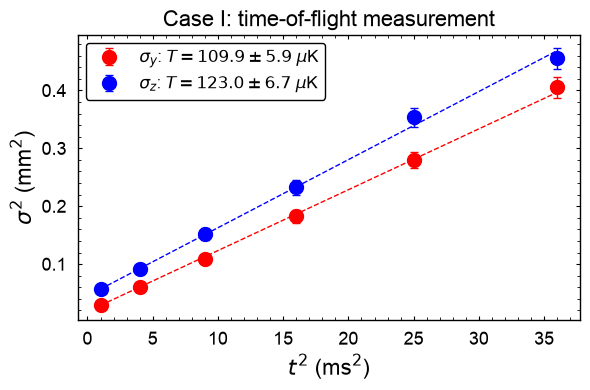


========== TOF FIT RESULTS: Case I ==========
Y temperature: 109.9 ± 5.9 uK total
    fit/extraction uncertainty: ± 3.948 uK
    calibration uncertainty:    ± 4.395 uK
    reduced chi^2:              0.15  (4 dof)
Z temperature: 123.0 ± 6.7 uK total
    fit/extraction uncertainty: ± 4.498 uK
    calibration uncertainty:    ± 4.920 uK
    reduced chi^2:              0.33  (4 dof)

Y/Z difference: 13.1 uK = 2.2 sigma (statistical)

Y initial sigma: 134.972 um
Z initial sigma: 212.383 um

Saved result figure to: /Users/andrei/code/ocpi/papers/ncomms2026-780pzt/figure4/Case I/results.png

Processing Case II...

Y sigmas [um]:  [190.5196783  229.87082322 299.57180386 381.8267989  453.07749464
 535.74340892]
Z sigmas [um]:  [251.96261296 282.83949073 346.24728944 423.06295696 487.66598714
 567.85217526]
Y sigma fit errors before floor [um]:  [0.76824884 0.95108466 1.10079964 2.00218885 1.76915734 3.82260555]
Z sigma fit errors before floor [um]:  [1.65577781 1.85721721 1.60718605 2.13235648

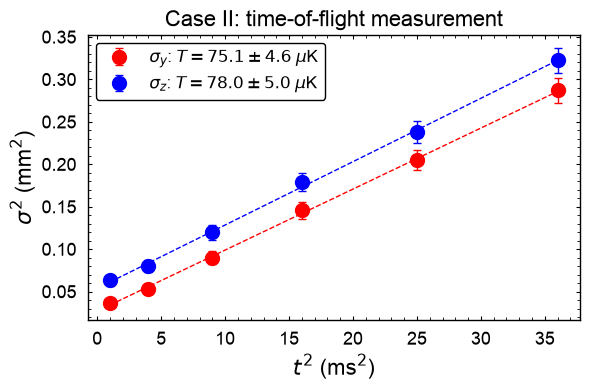


========== TOF FIT RESULTS: Case II ==========
Y temperature: 75.1 ± 4.6 uK total
    fit/extraction uncertainty: ± 3.481 uK
    calibration uncertainty:    ± 3.005 uK
    reduced chi^2:              0.16  (4 dof)
Z temperature: 78.0 ± 5.0 uK total
    fit/extraction uncertainty: ± 3.920 uK
    calibration uncertainty:    ± 3.121 uK
    reduced chi^2:              0.17  (4 dof)

Y/Z difference: 2.9 uK = 0.6 sigma (statistical)

Y initial sigma: 164.515 um
Z initial sigma: 232.022 um

Saved result figure to: /Users/andrei/code/ocpi/papers/ncomms2026-780pzt/figure4/Case II/results.png

Processing Case III...

Y sigmas [um]:  [125.02117783 141.1365274  161.45526426 195.62323564 223.52230341
 266.19230096]
Z sigmas [um]:  [140.25684249 160.34703778 183.07325298 215.80381584 241.0625374
 283.40679553]
Y sigma fit errors before floor [um]:  [0.6237167  0.86125838 0.97714012 1.09894117 1.45428755 1.55294809]
Z sigma fit errors before floor [um]:  [1.24194403 1.19385808 1.51695714 1.68577933 

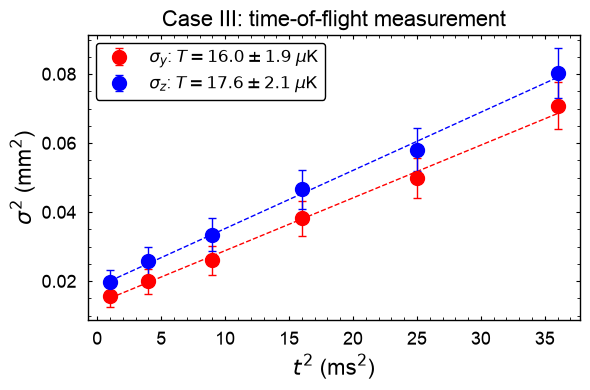


========== TOF FIT RESULTS: Case III ==========
Y temperature: 16.0 ± 1.9 uK total
    fit/extraction uncertainty: ± 1.823 uK
    calibration uncertainty:    ± 0.639 uK
    reduced chi^2:              0.08  (4 dof)
Z temperature: 17.6 ± 2.1 uK total
    fit/extraction uncertainty: ± 1.987 uK
    calibration uncertainty:    ± 0.704 uK
    reduced chi^2:              0.06  (4 dof)

Y/Z difference: 1.6 uK = 0.6 sigma (statistical)

Y initial sigma: 116.503 um
Z initial sigma: 135.652 um

Saved result figure to: /Users/andrei/code/ocpi/papers/ncomms2026-780pzt/figure4/Case III/results.png

Processing Case IV...

Y sigmas [um]:  [160.94965921 194.96701216 214.62311631 255.21234384 294.47639347
 335.01048183]
Z sigmas [um]:  [147.33125188 176.036801   221.16908354 258.95782353 311.9565613
 357.59914908]
Y sigma fit errors before floor [um]:  [0.75966442 0.88451183 1.07822757 1.76069249 1.9713806  2.43795428]
Z sigma fit errors before floor [um]:  [0.58968144 0.82388075 1.2903818  1.56913152

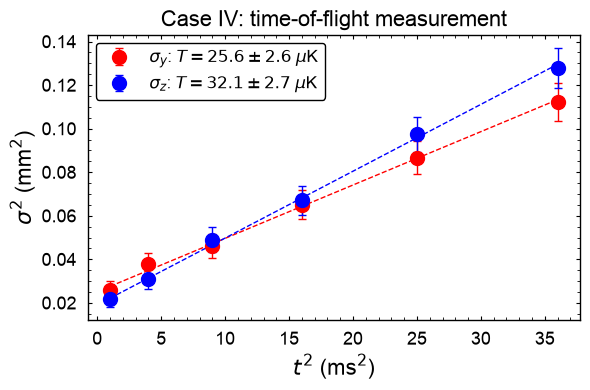


========== TOF FIT RESULTS: Case IV ==========
Y temperature: 25.6 ± 2.6 uK total
    fit/extraction uncertainty: ± 2.362 uK
    calibration uncertainty:    ± 1.024 uK
    reduced chi^2:              0.15  (4 dof)
Z temperature: 32.1 ± 2.7 uK total
    fit/extraction uncertainty: ± 2.407 uK
    calibration uncertainty:    ± 1.283 uK
    reduced chi^2:              0.07  (4 dof)

Y/Z difference: 6.5 uK = 1.9 sigma (statistical)

Y initial sigma: 158.481 um
Z initial sigma: 138.078 um

Saved result figure to: /Users/andrei/code/ocpi/papers/ncomms2026-780pzt/figure4/Case IV/results.png
    NOTE: Case I intercepts differ (y=0.0182, z=0.0451 mm^2); the average line will sit visibly between the two series.
    NOTE: Case II intercepts differ (y=0.0271, z=0.0538 mm^2); the average line will sit visibly between the two series.
Saved combined figure to: /Users/andrei/code/ocpi/papers/ncomms2026-780pzt/figure4/all_cases_tof
Saved publication figure to: /Users/andrei/code/ocpi/papers/ncomms2026-

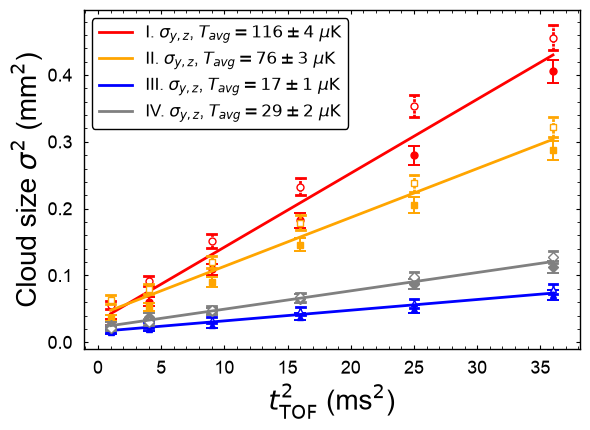

In [44]:
import matplotlib.pyplot as plt

# Clear anything left from a previous run so the count below is meaningful.
plt.close("all")

image_filenames = [
    '1_0ms',
    '2_0ms',
    '3_0ms',
    '4_0ms',
    '5_0ms',
    '6_0ms'
]

apply_collaborator_style()

all_results, fig = plot_all_cases_with_yz_errorbars(
    case_paths,
    image_filenames,
    out_dir=DATA_DIR
)

## Figure 5

In [45]:
def atom_number_calc(C_tots, I_tot, detuning, t_exp):
    # C_tot is the total (background subtracked) counts of the pixel values in MOT region of interest
    # I_tot is total brightness of illumination beams in mW/cm^2
    # Detuning (in MHz) is the cooling beam detuning from F'=3 transition
    # t_exp is the total camera exposure time in milliseconds
    
    detuning_ang = 2*np.pi*detuning
    
    Gamma = 2*np.pi*6.066 #(Rb-87 natural linewidth for the D2 5^2𝑆_1/2 → 5^2𝑃_3/2 transition, in angular MHz)
    I_sat = 3.577 #Rb-87 saturation intensity (in mW/cm^2) for that same transition
    
    G = 10.42 #Gain coefficient for camera sensor (in e-/LSB, least significant bit)
    eta_QM = 0.45 #quantum efficiency of camera at 780 nm (in e-/photon)
    
    eta_geo = 0.74 #portion of light collected to to an obstruction in imaging path
    Omega = 0.035 #Solid angle of light collection (in sterradians)
    
    R_scat = Gamma/2.0*((I_tot/I_sat)/(1+(I_tot/I_sat)+4*(detuning_ang/Gamma)**2))
    
    dN_gamma_dt = (4*np.pi*C_tots*G)/(Omega*eta_QM*eta_geo*t_exp)*10**(-3)
    
    Ns = dN_gamma_dt/R_scat
    
    return Ns


### Fig. 5b

#### Rb ref

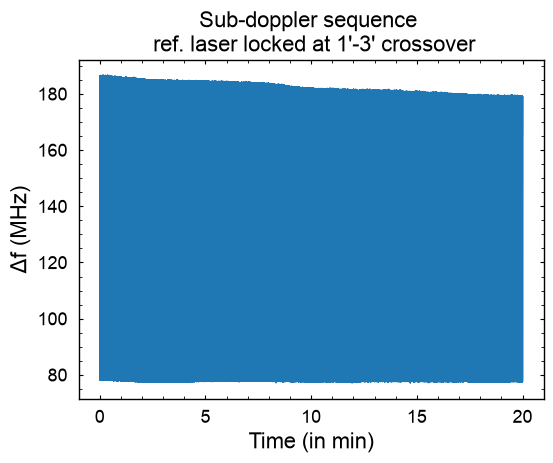

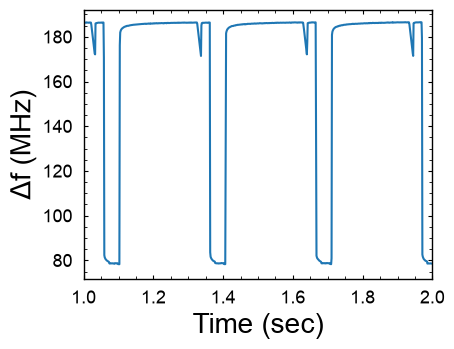

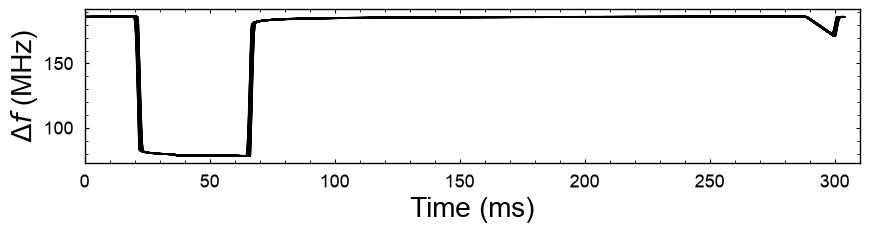

In [49]:
base_path = data_join('figure5', 'fig5bcd')
filename = 'BN_Rb_ref_DataLog-LONG_gate1.2ms.csv'
path = os.path.join(base_path, filename)
freq_data = np.genfromtxt(path, delimiter=",")
gatetime = 1.2e-3
fs = 1/gatetime
times = np.arange(len(freq_data))*gatetime

bn_times_Rb_ref = times
bn_freq_data_Rb_ref = freq_data

# convert MOT brightness to atom number
# with sat. spec. re-referencing
filename = 'Rb_ref_data_with_sat_spec.csv'
path = os.path.join(base_path, filename)
data_ss = pd.read_csv(path)
data_np_ss = data_ss.to_numpy()

times_ss = data_np_ss[:,0]
counts_per_px_ss = data_np_ss[:,1]

# specific to individual data collection
ROI_tot_px = 150*150
exp = 0.5*10 #10 frame accumulation for this data
C_tots_ss = ROI_tot_px*counts_per_px_ss
Ns_ss = atom_number_calc(C_tots_ss, 59.0/2, 25.5, exp)
mot_atomN_time_Rb_ref = times_ss
mot_atomN_brightness_Rb_ref = Ns_ss

plt.plot(times/60, freq_data/1e6)
plt.xlabel("Time (in min)")
plt.ylabel(r'$\Delta$f (MHz)')
plt.title("Sub-doppler sequence \n ref. laser locked at 1'-3' crossover")
plt.show()

plt.figure(figsize=(4.5,3.5))
plt.plot(times+0.05, freq_data/1e6, lw=1.5)
plt.xlabel("Time (sec)", fontsize=20)
plt.ylabel(r'$\Delta$f (MHz)', fontsize=20)
plt.xlim([1,2])
plt.show()


t_start = 0.075
period = 0.304028
period_mask = (times >= t_start) & (times < t_start + period)
times_period = times[period_mask]
freq_data_period = freq_data[period_mask]

# Calculate the number of complete periods we can extract from the data
end_time = times[-1]
n_periods = int((end_time - t_start) // period)
n_plot_periods = min(100, n_periods)  # Only plot the first 10 periods, or less if not enough data

plt.figure(figsize=(10,2))

def plot_period(ax, idx, label=None, color=None):
    segment_start = t_start + idx*period
    segment_end = segment_start + period
    segment_mask = (times >= segment_start) & (times < segment_end)
    times_segment = times[segment_mask] - segment_start  # reset time to 0 for each period
    freq_segment = freq_data[segment_mask] / 1e6  # MHz
    if len(times_segment) > 0:
        ax.plot(times_segment*1e3, freq_segment, ls='-', lw=1, alpha=0.8, label=label, color=color)

ax = plt.gca()

# Plot just the first 100 periods
for i in range(n_plot_periods):
    plot_period(ax, i, color='k')
plt.xlabel("Time (ms)", fontsize=20)
plt.ylabel(r"$\Delta f$ (MHz)", fontsize=20)
plt.xlim([0, 310])
plt.show()


#### Not Rb referenced

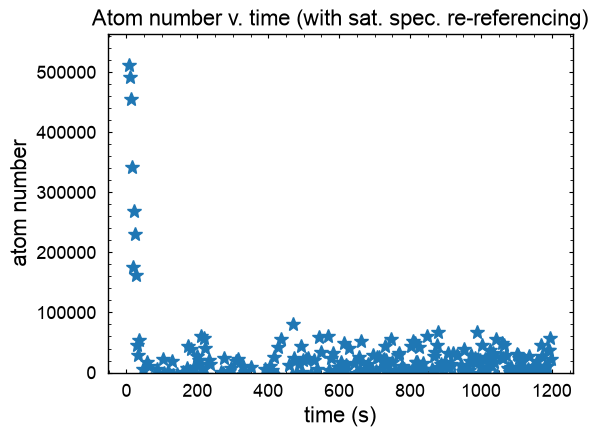

In [50]:
base_path = data_join('figure5', 'fig5bcd')
filename = 'BN_no_Rb_ref_DataLog-LONG-NOREREF_gate1.2ms.csv'
path = os.path.join(base_path, filename)
freq_data = np.genfromtxt(path, delimiter=",")
gatetime = 1.2e-3
fs = 1/gatetime
times = np.arange(len(freq_data))*gatetime

bn_times_no_Rb_ref = times
bn_freq_data_no_Rb_ref = freq_data

# convert MOT brightness to atom number
filename = 'no_Rb_ref_data_without_sat_spec.csv'
path = os.path.join(base_path, filename)
data_ss = pd.read_csv(path)
data_np_ss = data_ss.to_numpy()

times_ss = data_np_ss[:,0]
counts_per_px_ss = data_np_ss[:,1]

# specific to individual data collection
ROI_tot_px = 150*150
exp = 0.5*10 #10 frame accumulation for this data

C_tots_ss = ROI_tot_px*counts_per_px_ss

Ns_ss = atom_number_calc(C_tots_ss, 59.0/2, 25.5, exp)

plt.figure()
plt.plot(times_ss,Ns_ss,'*')
plt.title('Atom number v. time (with sat. spec. re-referencing)')
plt.xlabel('time (s)')
plt.ylabel('atom number')
plt.ylim(0, max(Ns_ss)*1.1)
plt.show()

mot_atomN_time_no_Rb_ref = times_ss
mot_atomN_brightness_no_Rb_ref = Ns_ss


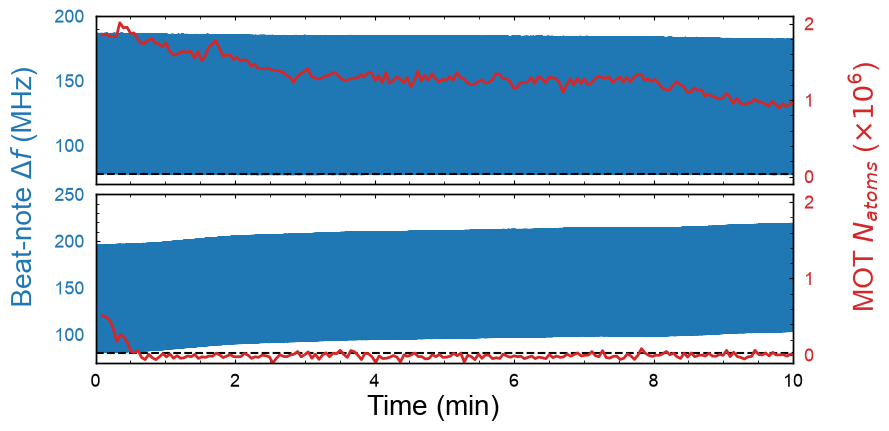

In [51]:

tmax = 10

# ---------- Split Y-axis setup ----------
fig, (ax1_top, ax1_bot) = plt.subplots(
    2, 1, sharex=True,
    figsize=(9, 4.5),
    gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.06}
)

# Right y-axis (one per subplot so the red trace stays continuous)
ax2_top = ax1_top.twinx()
ax2_bot = ax1_bot.twinx()

# ---------- Top section ----------
ax1_top.plot(bn_times_Rb_ref/60, bn_freq_data_Rb_ref/1e6,color='tab:blue', label='Rb ref')
ax1_top.axhline(78, ls='--', color='k', lw=1.5)
ax1_top.set_ylim(70, 200)
ax1_top.set_xlim(0, tmax)

# ---------- Bottom section ----------
ax1_bot.plot(bn_times_no_Rb_ref/60, bn_freq_data_no_Rb_ref/1e6, color='tab:blue', lw=1, label='No Rb ref')
ax1_bot.axhline(np.min(bn_freq_data_no_Rb_ref/1e6),ls='--', lw=1.5, color='k')
ax1_bot.set_ylim(70, 250)
ax1_bot.set_xlim(0, tmax)

# ---------- Right axis: MOT signal ----------
ax2_top.plot(mot_atomN_time_Rb_ref/60, mot_atomN_brightness_Rb_ref/1e6, color='tab:red', lw=2)#, label='Mean MOT brightness')
ax2_top.tick_params(axis='y', labelcolor='tab:red')
ax2_top.set_ylim(-0.1, 2.1)
ax2_top.set_xlim(0, tmax)

ax2_bot.plot(mot_atomN_time_no_Rb_ref/60, mot_atomN_brightness_no_Rb_ref/1e6, color='tab:red', lw=2)#, label='Mean MOT brightness')
ax2_bot.tick_params(axis='y', labelcolor='tab:red')
ax2_bot.set_ylim(-0.1, 2.1)
ax2_bot.set_xlim(0, tmax)

fig.supxlabel("Time (min)", fontsize=20, y=-0.02)
fig.supylabel(r"Beat-note $\Delta f$ (MHz)", x=0.03, fontsize=20, color='tab:blue')

fig.text(0.96, 0.5, r"MOT $N_{atoms}$ ($\times 10^6$)", va='center', rotation=90,
         color='tab:red', fontsize=20)

for ax in (ax1_top, ax1_bot):
    ax.tick_params(axis='y', labelcolor='tab:blue')

ax1_top.tick_params(labelbottom=False)

# ---------- Legend (combine both axes’ handles) ----------
lines1, labels1 = ax1_top.get_legend_handles_labels()
lines2, labels2 = ax1_bot.get_legend_handles_labels()

plt.show()

### Fig. 5e

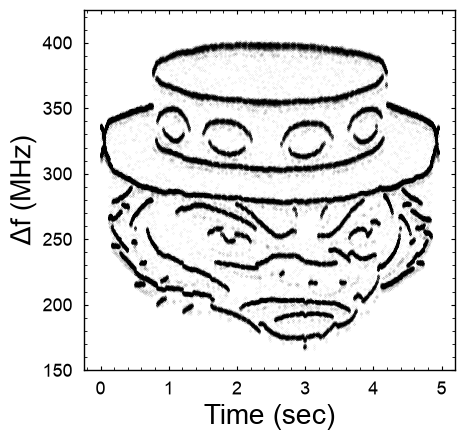

In [52]:
base_path = data_join('figure5', 'fig5e')
filename = 'DataLogBob-10US.0_longer_Rbref.csv'
path = os.path.join(base_path, filename)
freq_data1 = np.genfromtxt(path, delimiter=",")
gatetime = 10/0.8*2e-6
fs = 1/gatetime
times1 = np.arange(len(freq_data1)) * gatetime

# Select just one cycle in the times [19.6, 24.55]
cycle_mask1 = (times1 >= 19.6) & (times1 <= 24.55)
cycle_times1 = times1[cycle_mask1]
cycle_freq_data1 = freq_data1[cycle_mask1]

plt.figure(figsize=(4.75,4.5))
plt.plot(cycle_times1 - cycle_times1[0], cycle_freq_data1/1e6, marker='.', markersize=0.075, ls='', label='Rb ref',  color='k')
plt.ylim([150, 425])
plt.xlabel("Time (sec)", fontsize=20)
plt.ylabel(r'$\Delta$f (MHz)', fontsize=20)
plt.tight_layout()
plt.show()
